In [58]:

# AGMR — Aksanti Global Market Research
#
# QM640 Data Analytics Capstone | Príncipe Zanguilo | Walsh College
#



In [ ]:
# Data Preparation for time series analysis
#   1. Transforms daily USD/AOA → monthly (median of daily values per month)
#   2. Transforms annual Real Interest Rate → monthly (year value replicated
#      across all 12 months of that year)
#   3. Merges all 7 series into a single monthly panel (outer join, no cleaning)
#
#
#   - cpi_inflation_pct_monthly_2011_2026.csv
#   - usd_aoa_daily_1994_2026.csv
#   - real_interest_rate_pct_anual_1995_2024.csv
#   - oil_brent_usd_bbl_monthly_1992_2026.csv
#   - nat_gas_usd_mmbu_monthly_1992_2026.csv
#   - diamond_usd_carat_monthly_1992_2026.csv
#   - gold_usd_monthly_1833_2026.csv

In [59]:
# Mounting Google Drive and setting file paths
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


DATA_DIR = '/content/drive/MyDrive/AGMR/timeseries/raw'



Mounted at /content/drive


In [60]:
# Output file to be saved in the same folder of the data
OUTPUT_FILE = os.path.join(DATA_DIR, 'agmr_panel_7series_monthly.csv')

In [83]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import os
import warnings
warnings.filterwarnings('ignore')
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

print("Libraries loaded ✓")

Libraries loaded ✓


In [62]:
# Loading CPI Inflation Series
#
# Source : WFP DataViz / Trading Economics / BNA
# Period : 1991-01 to 2026-03
# Unit   : % monthly change


cpi = pd.read_csv(os.path.join(DATA_DIR, 'cpi_inflation_pct_monthly_1991_2026.csv'))

# Rename columns to standard names
cpi.columns = ['date', 'cpi_inflation_pct']

# Parse date: format is "Mar/2026"
cpi['date'] = pd.to_datetime(cpi['date'], format='%b/%Y')

# Convert value column to numeric (empty rows become NaN)
cpi['cpi_inflation_pct'] = pd.to_numeric(cpi['cpi_inflation_pct'], errors='coerce')

# Sort chronologically and set date to month-start
cpi = cpi.sort_values('date').reset_index(drop=True)

print("── CPI Inflation ──────────────────────────────────────────")
print(f"  Rows       : {len(cpi)}")
print(f"  Period     : {cpi['date'].min().strftime('%Y-%m')} → {cpi['date'].max().strftime('%Y-%m')}")
print(f"  NaN values : {cpi['cpi_inflation_pct'].isna().sum()}  (rows outside source coverage)")
print(cpi.head(3))

── CPI Inflation ──────────────────────────────────────────
  Rows       : 423
  Period     : 1991-01 → 2026-03
  NaN values : 0  (rows outside source coverage)
        date  cpi_inflation_pct
0 1991-01-01            31.3900
1 1991-02-01             6.6900
2 1991-03-01             3.6900


In [63]:
# Transforming USD/AOA — daily into monthly using the median
#
# Source : WFP DataViz / BNA
# Period : 1994-12-14 to 2026-05
# Unit   : Kz per USD (daily rate)
# Method : median of all trading days within each calendar month


fx_daily = pd.read_csv(os.path.join(DATA_DIR, 'usd_aoa_daily_1994_2026.csv'))

fx_daily.columns = ['date', 'usd_aoa_daily']

# Parse date: format is "DD/MM/YYYY"
fx_daily['date'] = pd.to_datetime(fx_daily['date'], dayfirst=True)

fx_daily['usd_aoa_daily'] = pd.to_numeric(fx_daily['usd_aoa_daily'], errors='coerce')

fx_daily = fx_daily.sort_values('date').reset_index(drop=True)

# Aggregate to monthly using MEDIAN
# resample('MS') anchors each period to the 1st of the month (Month Start)
fx_monthly = (
    fx_daily
    .set_index('date')['usd_aoa_daily']
    .resample('MS')
    .median()
    .reset_index()
)
fx_monthly.columns = ['date', 'usd_aoa_monthly']

print("── USD/AOA ─────────────────────────────────────────────────")
print(f"  Daily rows     : {len(fx_daily)}")
print(f"  Monthly rows   : {len(fx_monthly)}")
print(f"  Period         : {fx_monthly['date'].min().strftime('%Y-%m')} → {fx_monthly['date'].max().strftime('%Y-%m')}")
print(f"  NaN months     : {fx_monthly['usd_aoa_monthly'].isna().sum()}")
print(fx_monthly.head(3))

── USD/AOA ─────────────────────────────────────────────────
  Daily rows     : 8159
  Monthly rows   : 378
  Period         : 1994-12 → 2026-05
  NaN months     : 0
        date  usd_aoa_monthly
0 1994-12-01           0.4992
1 1995-01-01           0.5246
2 1995-02-01           0.5514


In [64]:
# Transforming Real Interest Rate — annual to monthly by replication
#
# Source : World Bank (FR.INR.RINR)
# Period : 1995 → 2025
# Unit   : % annual
# Method : Each year's value is replicated for all 12 months of that year
#          (months are created as YYYY-01-01 through YYYY-12-01)

rir_annual = pd.read_csv(os.path.join(DATA_DIR, 'real_interest_rate_pct_anual_1995_2025.csv'))

rir_annual.columns = ['year', 'real_interest_rate_annual']

rir_annual['year'] = pd.to_numeric(rir_annual['year'], errors='coerce').astype('Int64')
rir_annual['real_interest_rate_annual'] = pd.to_numeric(
    rir_annual['real_interest_rate_annual'], errors='coerce'
)

rir_annual = rir_annual.dropna(subset=['year']).sort_values('year').reset_index(drop=True)

# Replicate each annual value across 12 monthly rows
monthly_rows = []
for _, row in rir_annual.iterrows():
    yr = int(row['year'])
    val = row['real_interest_rate_annual']
    for month in range(1, 13):
        monthly_rows.append({
            'date': pd.Timestamp(year=yr, month=month, day=1),
            'real_interest_rate_monthly': val
        })

rir_monthly = pd.DataFrame(monthly_rows)
rir_monthly = rir_monthly.sort_values('date').reset_index(drop=True)

print("── Real Interest Rate ──────────────────────────────────────")
print(f"  Annual rows    : {len(rir_annual)}")
print(f"  Monthly rows   : {len(rir_monthly)}  ({len(rir_annual)} years × 12 months)")
print(f"  Period         : {rir_monthly['date'].min().strftime('%Y-%m')} → {rir_monthly['date'].max().strftime('%Y-%m')}")
print(f"  NaN values     : {rir_monthly['real_interest_rate_monthly'].isna().sum()}")
print(rir_monthly.head(3))

── Real Interest Rate ──────────────────────────────────────
  Annual rows    : 31
  Monthly rows   : 372  (31 years × 12 months)
  Period         : 1995-01 → 2025-12
  NaN values     : 0
        date  real_interest_rate_monthly
0 1995-01-01                    -84.0950
1 1995-02-01                    -84.0950
2 1995-03-01                    -84.0950


In [65]:
# Loading the commodity series
#
# All four series are sourced from FRED and are already at monthly frequency.

# ── Brent Crude Oil
oil = pd.read_csv(os.path.join(DATA_DIR, 'oil_brent_usd_bbl_monthly_1992_2026.csv'))
oil.columns = ['date', 'oil_brent_usd_bbl']
oil['date'] = pd.to_datetime(oil['date'])
oil['oil_brent_usd_bbl'] = pd.to_numeric(oil['oil_brent_usd_bbl'], errors='coerce')
oil = oil.sort_values('date').reset_index(drop=True)

print("── Brent Crude Oil ─────────────────────────────────────────")
print(f"  Rows: {len(oil)}  |  Period: {oil['date'].min().strftime('%Y-%m')} → {oil['date'].max().strftime('%Y-%m')}  |  NaN: {oil['oil_brent_usd_bbl'].isna().sum()}")

# ── Natural Gas EU
gas = pd.read_csv(os.path.join(DATA_DIR, 'nat_gas_usd_mmbu_monthly_1992_2026.csv'))
gas.columns = ['date', 'nat_gas_usd_mmbtu']
gas['date'] = pd.to_datetime(gas['date'])
gas['nat_gas_usd_mmbtu'] = pd.to_numeric(gas['nat_gas_usd_mmbtu'], errors='coerce')
gas = gas.sort_values('date').reset_index(drop=True)

print("── Natural Gas EU ──────────────────────────────────────────")
print(f"  Rows: {len(gas)}  |  Period: {gas['date'].min().strftime('%Y-%m')} → {gas['date'].max().strftime('%Y-%m')}  |  NaN: {gas['nat_gas_usd_mmbtu'].isna().sum()}")

# ── Diamond Import Price Index
diamond = pd.read_csv(os.path.join(DATA_DIR, 'diamond_usd_carat_monthly_1992_2026.csv'))
diamond.columns = ['date', 'diamond_usd_carat']
diamond['date'] = pd.to_datetime(diamond['date'])
diamond['diamond_usd_carat'] = pd.to_numeric(diamond['diamond_usd_carat'], errors='coerce')
diamond = diamond.sort_values('date').reset_index(drop=True)

print("── Diamond Index ───────────────────────────────────────────")
print(f"  Rows: {len(diamond)}  |  Period: {diamond['date'].min().strftime('%Y-%m')} → {diamond['date'].max().strftime('%Y-%m')}  |  NaN: {diamond['diamond_usd_carat'].isna().sum()}")

# ── Gold PPI
gold = pd.read_csv(os.path.join(DATA_DIR, 'gold_usd_monthly_1833_2026.csv'))
gold.columns = ['date', 'gold_usd']
gold['date'] = pd.to_datetime(gold['date'])
gold['gold_usd'] = pd.to_numeric(gold['gold_usd'], errors='coerce')
gold = gold.sort_values('date').reset_index(drop=True)

print("── Gold PPI ────────────────────────────────────────────────")
print(f"  Rows: {len(gold)}  |  Period: {gold['date'].min().strftime('%Y-%m')} → {gold['date'].max().strftime('%Y-%m')}  |  NaN: {gold['gold_usd'].isna().sum()}")



── Brent Crude Oil ─────────────────────────────────────────
  Rows: 411  |  Period: 1992-01 → 2026-03  |  NaN: 0
── Natural Gas EU ──────────────────────────────────────────
  Rows: 411  |  Period: 1992-01 → 2026-03  |  NaN: 0
── Diamond Index ───────────────────────────────────────────
  Rows: 400  |  Period: 1992-12 → 2026-03  |  NaN: 34
── Gold PPI ────────────────────────────────────────────────
  Rows: 2319  |  Period: 1833-01 → 2026-03  |  NaN: 0


In [66]:
# Merging all the 7 series into a single monthly panel data
#
# Method : successive outer joins on 'date'
#          outer join preserves every date present in ANY series
#          no rows dropped, no values imputed — NaN where a series has no data


all_series = [cpi, fx_monthly, rir_monthly, oil, gas, diamond, gold]

panel = all_series[0].copy()
for df in all_series[1:]:
    panel = pd.merge(panel, df, on='date', how='outer')

# Final sort by date
panel = panel.sort_values('date').reset_index(drop=True)

# Confirm column order
COLUMNS = [
    'date',
    'cpi_inflation_pct',
    'usd_aoa_monthly',
    'real_interest_rate_monthly',
    'oil_brent_usd_bbl',
    'nat_gas_usd_mmbtu',
    'diamond_usd_carat',
    'gold_usd',
]
panel = panel[COLUMNS]

print("\n══════════════════════════════════════════════════════════════")
print("MERGED PANEL — SUMMARY")
print("══════════════════════════════════════════════════════════════")
print(f"  Total rows    : {len(panel)}")
print(f"  Total columns : {len(panel.columns)}  {list(panel.columns)}")
print(f"  Date range    : {panel['date'].min().strftime('%Y-%m')} → {panel['date'].max().strftime('%Y-%m')}")
print(f"\n  NaN count per series:")
for col in COLUMNS[1:]:
    n = panel[col].isna().sum()
    avail = panel[col].notna().sum()
    start = panel.loc[panel[col].notna(), 'date'].min().strftime('%Y-%m')
    end   = panel.loc[panel[col].notna(), 'date'].max().strftime('%Y-%m')
    print(f"    {col:<35}  NaN={n:3d}  available={avail:3d}  ({start} → {end})")

print("\n  First 5 rows of panel:")
print(panel.head(5).to_string(index=False))
print("\n  Last 5 rows of panel:")
print(panel.tail(5).to_string(index=False))




══════════════════════════════════════════════════════════════
MERGED PANEL — SUMMARY
══════════════════════════════════════════════════════════════
  Total rows    : 2321
  Total columns : 8  ['date', 'cpi_inflation_pct', 'usd_aoa_monthly', 'real_interest_rate_monthly', 'oil_brent_usd_bbl', 'nat_gas_usd_mmbtu', 'diamond_usd_carat', 'gold_usd']
  Date range    : 1833-01 → 2026-05

  NaN count per series:
    cpi_inflation_pct                    NaN=1898  available=423  (1991-01 → 2026-03)
    usd_aoa_monthly                      NaN=1943  available=378  (1994-12 → 2026-05)
    real_interest_rate_monthly           NaN=1949  available=372  (1995-01 → 2025-12)
    oil_brent_usd_bbl                    NaN=1910  available=411  (1992-01 → 2026-03)
    nat_gas_usd_mmbtu                    NaN=1910  available=411  (1992-01 → 2026-03)
    diamond_usd_carat                    NaN=1955  available=366  (1992-12 → 2026-03)
    gold_usd                             NaN=  2  available=2319  (1833-01 

In [67]:
# Save merged panel data to CSV

panel.to_csv(OUTPUT_FILE, index=False, date_format='%Y-%m-%d')
print(f"\nPanel saved → {OUTPUT_FILE}")
print(f"Shape: {panel.shape[0]} rows × {panel.shape[1]} columns")


Panel saved → /content/drive/MyDrive/AGMR/timeseries/raw/agmr_panel_7series_monthly.csv
Shape: 2321 rows × 8 columns


In [97]:
OUTPUT_DIR = '/content/drive/MyDrive/AGMR/outputs/figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

PANEL_FILE = os.path.join(DATA_DIR, 'agmr_panel_7series_monthly.csv')

In [98]:
# Loading the panel data

panel = pd.read_csv(PANEL_FILE, parse_dates=['date'])
panel = panel.sort_values('date').reset_index(drop=True)

print(f"Panel loaded: {panel.shape[0]} rows × {panel.shape[1]} columns")
print(f"Date range  : {panel['date'].min().strftime('%Y-%m')} → {panel['date'].max().strftime('%Y-%m')}")
print(panel.info())


Panel loaded: 2321 rows × 8 columns
Date range  : 1833-01 → 2026-05
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2321 entries, 0 to 2320
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   date                        2321 non-null   datetime64[ns]
 1   cpi_inflation_pct           423 non-null    float64       
 2   usd_aoa_monthly             378 non-null    float64       
 3   real_interest_rate_monthly  372 non-null    float64       
 4   oil_brent_usd_bbl           411 non-null    float64       
 5   nat_gas_usd_mmbtu           411 non-null    float64       
 6   diamond_usd_carat           366 non-null    float64       
 7   gold_usd                    2319 non-null   float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 145.2 KB
None


In [99]:
# Ploting all 7 series from agmr_panel_7series_monthly.csv
#   - Figure 1 : Macroeconomic Group  (3 subplots: CPI, USD/AOA, Real Rate)
#   - Figure 2 : Commodity Group      (4 subplots: Oil, Gas, Diamond, Gold)
#   - Figure 3 : Full 7-series dashboard (single figure, all panels)
#
# Vertical dashed lines mark Angola's 6 structural break dates:
#   2002 (post-civil war), 2008 (GFC), 2014 (oil shock), 2016 (devaluation),
#   2020 (pandemic), 2022 (fiscal adjustment)



# Configuration

# Angola structural break years
BREAKS = [2002, 2008, 2014, 2016, 2020, 2022]
BREAK_DATES = [pd.Timestamp(f'{y}-01-01') for y in BREAKS]

# Colour palette
C_MACRO     = '#1F3864'   # dark navy   — macro group
C_COMMODITY = '#922B21'   # dark red    — commodity group
C_BREAK     = '#E67E22'   # amber       — structural break lines
C_FILL      = 0.07        # fill alpha

# Series metadata: (column, label, y-axis unit, group, colour)
SERIES = [
    # Macroeconomic Group
    ('cpi_inflation_pct',          'CPI Inflation',         '% monthly',    'macro',     C_MACRO),
    ('usd_aoa_monthly',            'USD / AOA Exchange Rate','Kz per USD',  'macro',     C_MACRO),
    ('real_interest_rate_monthly', 'Real Interest Rate',    '% annual',     'macro',     C_MACRO),
    # Commodity Group
    ('oil_brent_usd_bbl',          'Brent Crude Oil',       'USD / bbl',    'commodity', C_COMMODITY),
    ('nat_gas_usd_mmbtu',          'Natural Gas (EU)',       'USD / mmbtu',  'commodity', C_COMMODITY),
    ('diamond_usd_carat',          'Diamond Index',         'Index 2000=100','commodity',C_COMMODITY),
    ('gold_usd',                   'Gold PPI',              'USD / oz',     'commodity', C_COMMODITY),
]

# Shared plot style
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.linestyle'   : ':',
    'grid.alpha'       : 0.35,
    'grid.color'       : '#AAAAAA',
})


# Helper: annotate structural break lines

def add_break_lines(ax, label_top=True):
    """Draw vertical dashed lines at each structural break date."""
    ymin, ymax = ax.get_ylim()
    for i, bd in enumerate(BREAK_DATES):
        ax.axvline(bd, color=C_BREAK, linewidth=0.9, linestyle='--', alpha=0.75, zorder=1)
        if label_top:
            ax.text(
                bd, ymax * 0.97,
                str(BREAKS[i]),
                fontsize=6.5, color=C_BREAK, ha='center', va='top',
                fontweight='bold'
            )


# Helper: format x-axis as years

def fmt_xaxis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_minor_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.get_xticklabels(), rotation=0, fontsize=8)


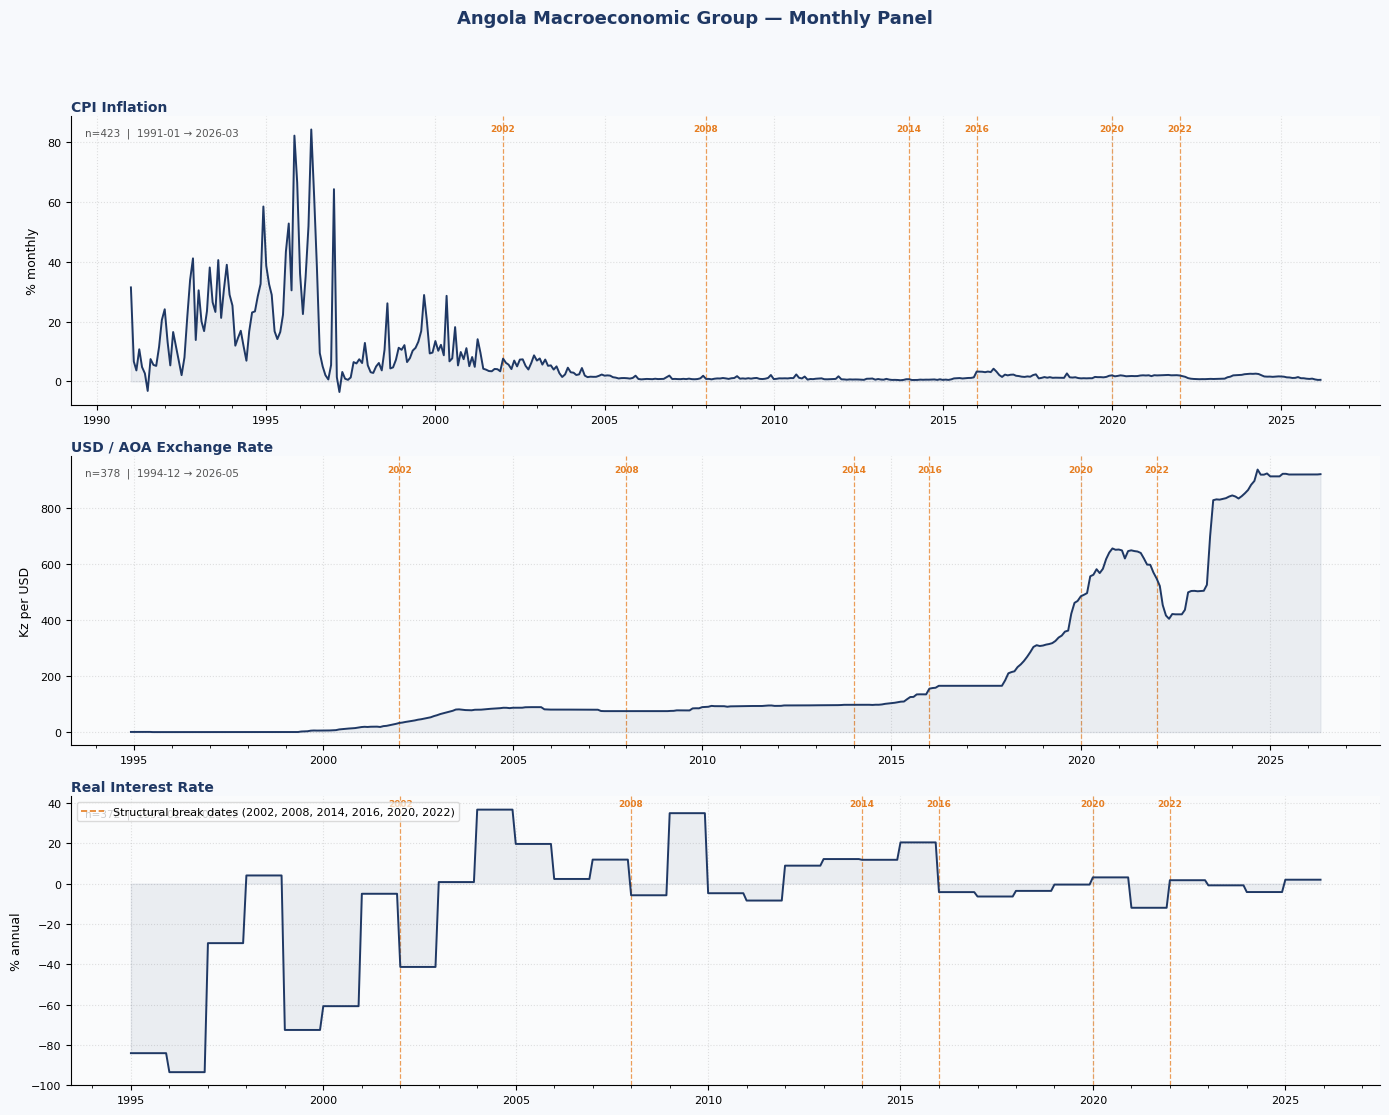

Figure 1 saved → /content/drive/MyDrive/AGMR/outputs/figures/fig1_macro_group.png


In [100]:
# Figure 1 — Macroeconomic Group


macro_series = [s for s in SERIES if s[4] == C_MACRO]  # 3 series

fig1, axes = plt.subplots(3, 1, figsize=(14, 11), facecolor='#F7F9FC')
fig1.suptitle(
    'Angola Macroeconomic Group — Monthly Panel\n',
    fontsize=13, fontweight='bold', color='#1F3864', y=1.01
)

for ax, (col, label, unit, _, color) in zip(axes, macro_series):
    sub = panel[['date', col]].dropna()

    ax.set_facecolor('#FAFBFC')
    ax.plot(sub['date'], sub[col], color=color, linewidth=1.4, zorder=3)
    ax.fill_between(sub['date'], sub[col], alpha=C_FILL, color=color, zorder=2)

    ax.set_ylabel(unit, fontsize=9, labelpad=6)
    ax.set_title(label, fontsize=10, fontweight='bold', color=color, loc='left', pad=4)

    # Data availability annotation
    ax.annotate(
        f"n={len(sub)}  |  {sub['date'].min().strftime('%Y-%m')} → {sub['date'].max().strftime('%Y-%m')}",
        xy=(0.01, 0.96), xycoords='axes fraction',
        fontsize=7.5, color='#555555', va='top'
    )

    fmt_xaxis(ax)
    ax.tick_params(axis='y', labelsize=8)
    add_break_lines(ax, label_top=True)

# Shared break-line legend on bottom subplot
legend_elements = [
    Line2D([0], [0], color=C_BREAK, linewidth=1.2, linestyle='--',
           label='Structural break dates (2002, 2008, 2014, 2016, 2020, 2022)')
]
axes[-1].legend(handles=legend_elements, loc='upper left', fontsize=8,
                framealpha=0.7, edgecolor='#CCCCCC')

plt.tight_layout(rect=[0, 0, 1, 0.99])

path1 = os.path.join(OUTPUT_DIR, 'fig1_macro_group.png')
fig1.savefig(path1, dpi=180, bbox_inches='tight', facecolor=fig1.get_facecolor())
plt.show()
print(f"Figure 1 saved → {path1}")

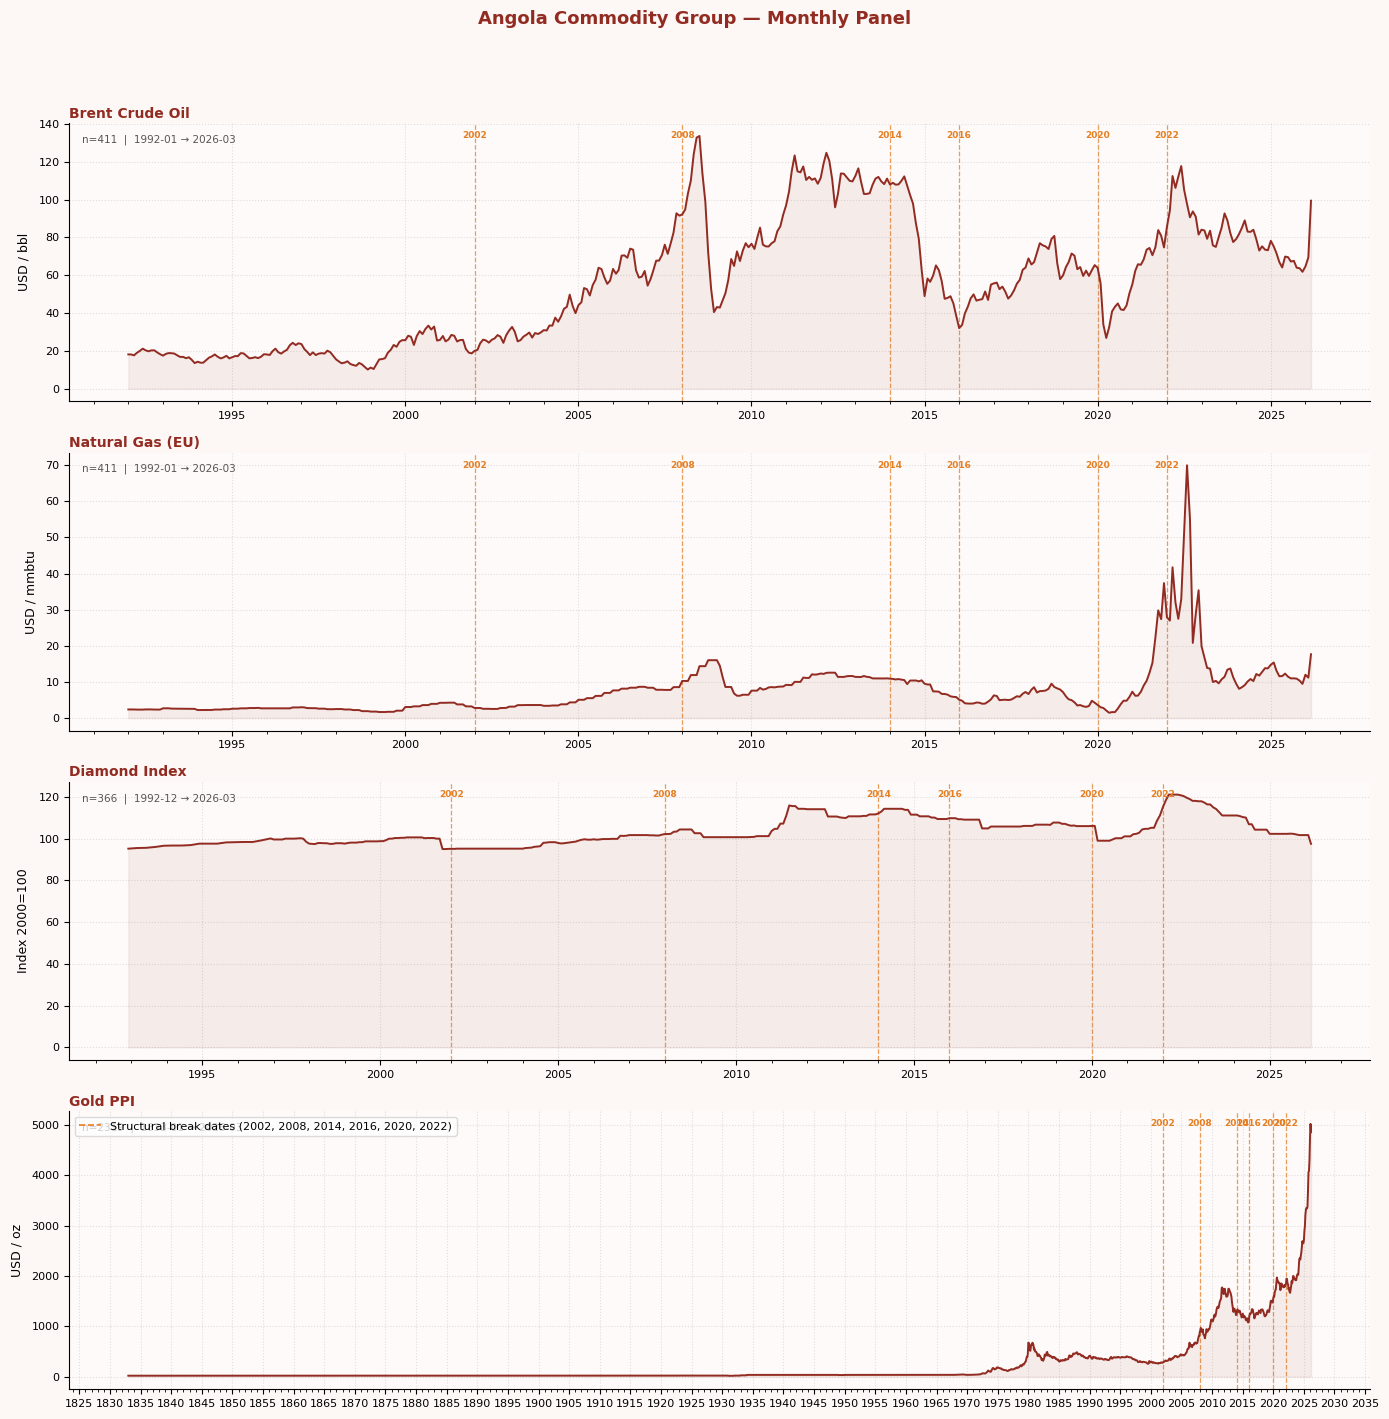

Figure 2 saved → /content/drive/MyDrive/AGMR/outputs/figures/fig2_commodity_group.png


In [101]:

# Figure 2 — Commodity Group


comm_series = [s for s in SERIES if s[4] == C_COMMODITY]   # 4 series

fig2, axes = plt.subplots(4, 1, figsize=(14, 14), facecolor='#FDF7F6')
fig2.suptitle(
    'Angola Commodity Group — Monthly Panel\n',
    fontsize=13, fontweight='bold', color='#922B21', y=1.01
)

for ax, (col, label, unit, _, color) in zip(axes, comm_series):
    sub = panel[['date', col]].dropna()

    ax.set_facecolor('#FDFAF9')
    ax.plot(sub['date'], sub[col], color=color, linewidth=1.4, zorder=3)
    ax.fill_between(sub['date'], sub[col], alpha=C_FILL, color=color, zorder=2)

    ax.set_ylabel(unit, fontsize=9, labelpad=6)
    ax.set_title(label, fontsize=10, fontweight='bold', color=color, loc='left', pad=4)

    ax.annotate(
        f"n={len(sub)}  |  {sub['date'].min().strftime('%Y-%m')} → {sub['date'].max().strftime('%Y-%m')}",
        xy=(0.01, 0.96), xycoords='axes fraction',
        fontsize=7.5, color='#555555', va='top'
    )

    fmt_xaxis(ax)
    ax.tick_params(axis='y', labelsize=8)
    add_break_lines(ax, label_top=True)

legend_elements = [
    Line2D([0], [0], color=C_BREAK, linewidth=1.2, linestyle='--',
           label='Structural break dates (2002, 2008, 2014, 2016, 2020, 2022)')
]
axes[-1].legend(handles=legend_elements, loc='upper left', fontsize=8,
                framealpha=0.7, edgecolor='#CCCCCC')

plt.tight_layout(rect=[0, 0, 1, 0.99])

path2 = os.path.join(OUTPUT_DIR, 'fig2_commodity_group.png')
fig2.savefig(path2, dpi=180, bbox_inches='tight', facecolor=fig2.get_facecolor())
plt.show()
print(f"Figure 2 saved → {path2}")

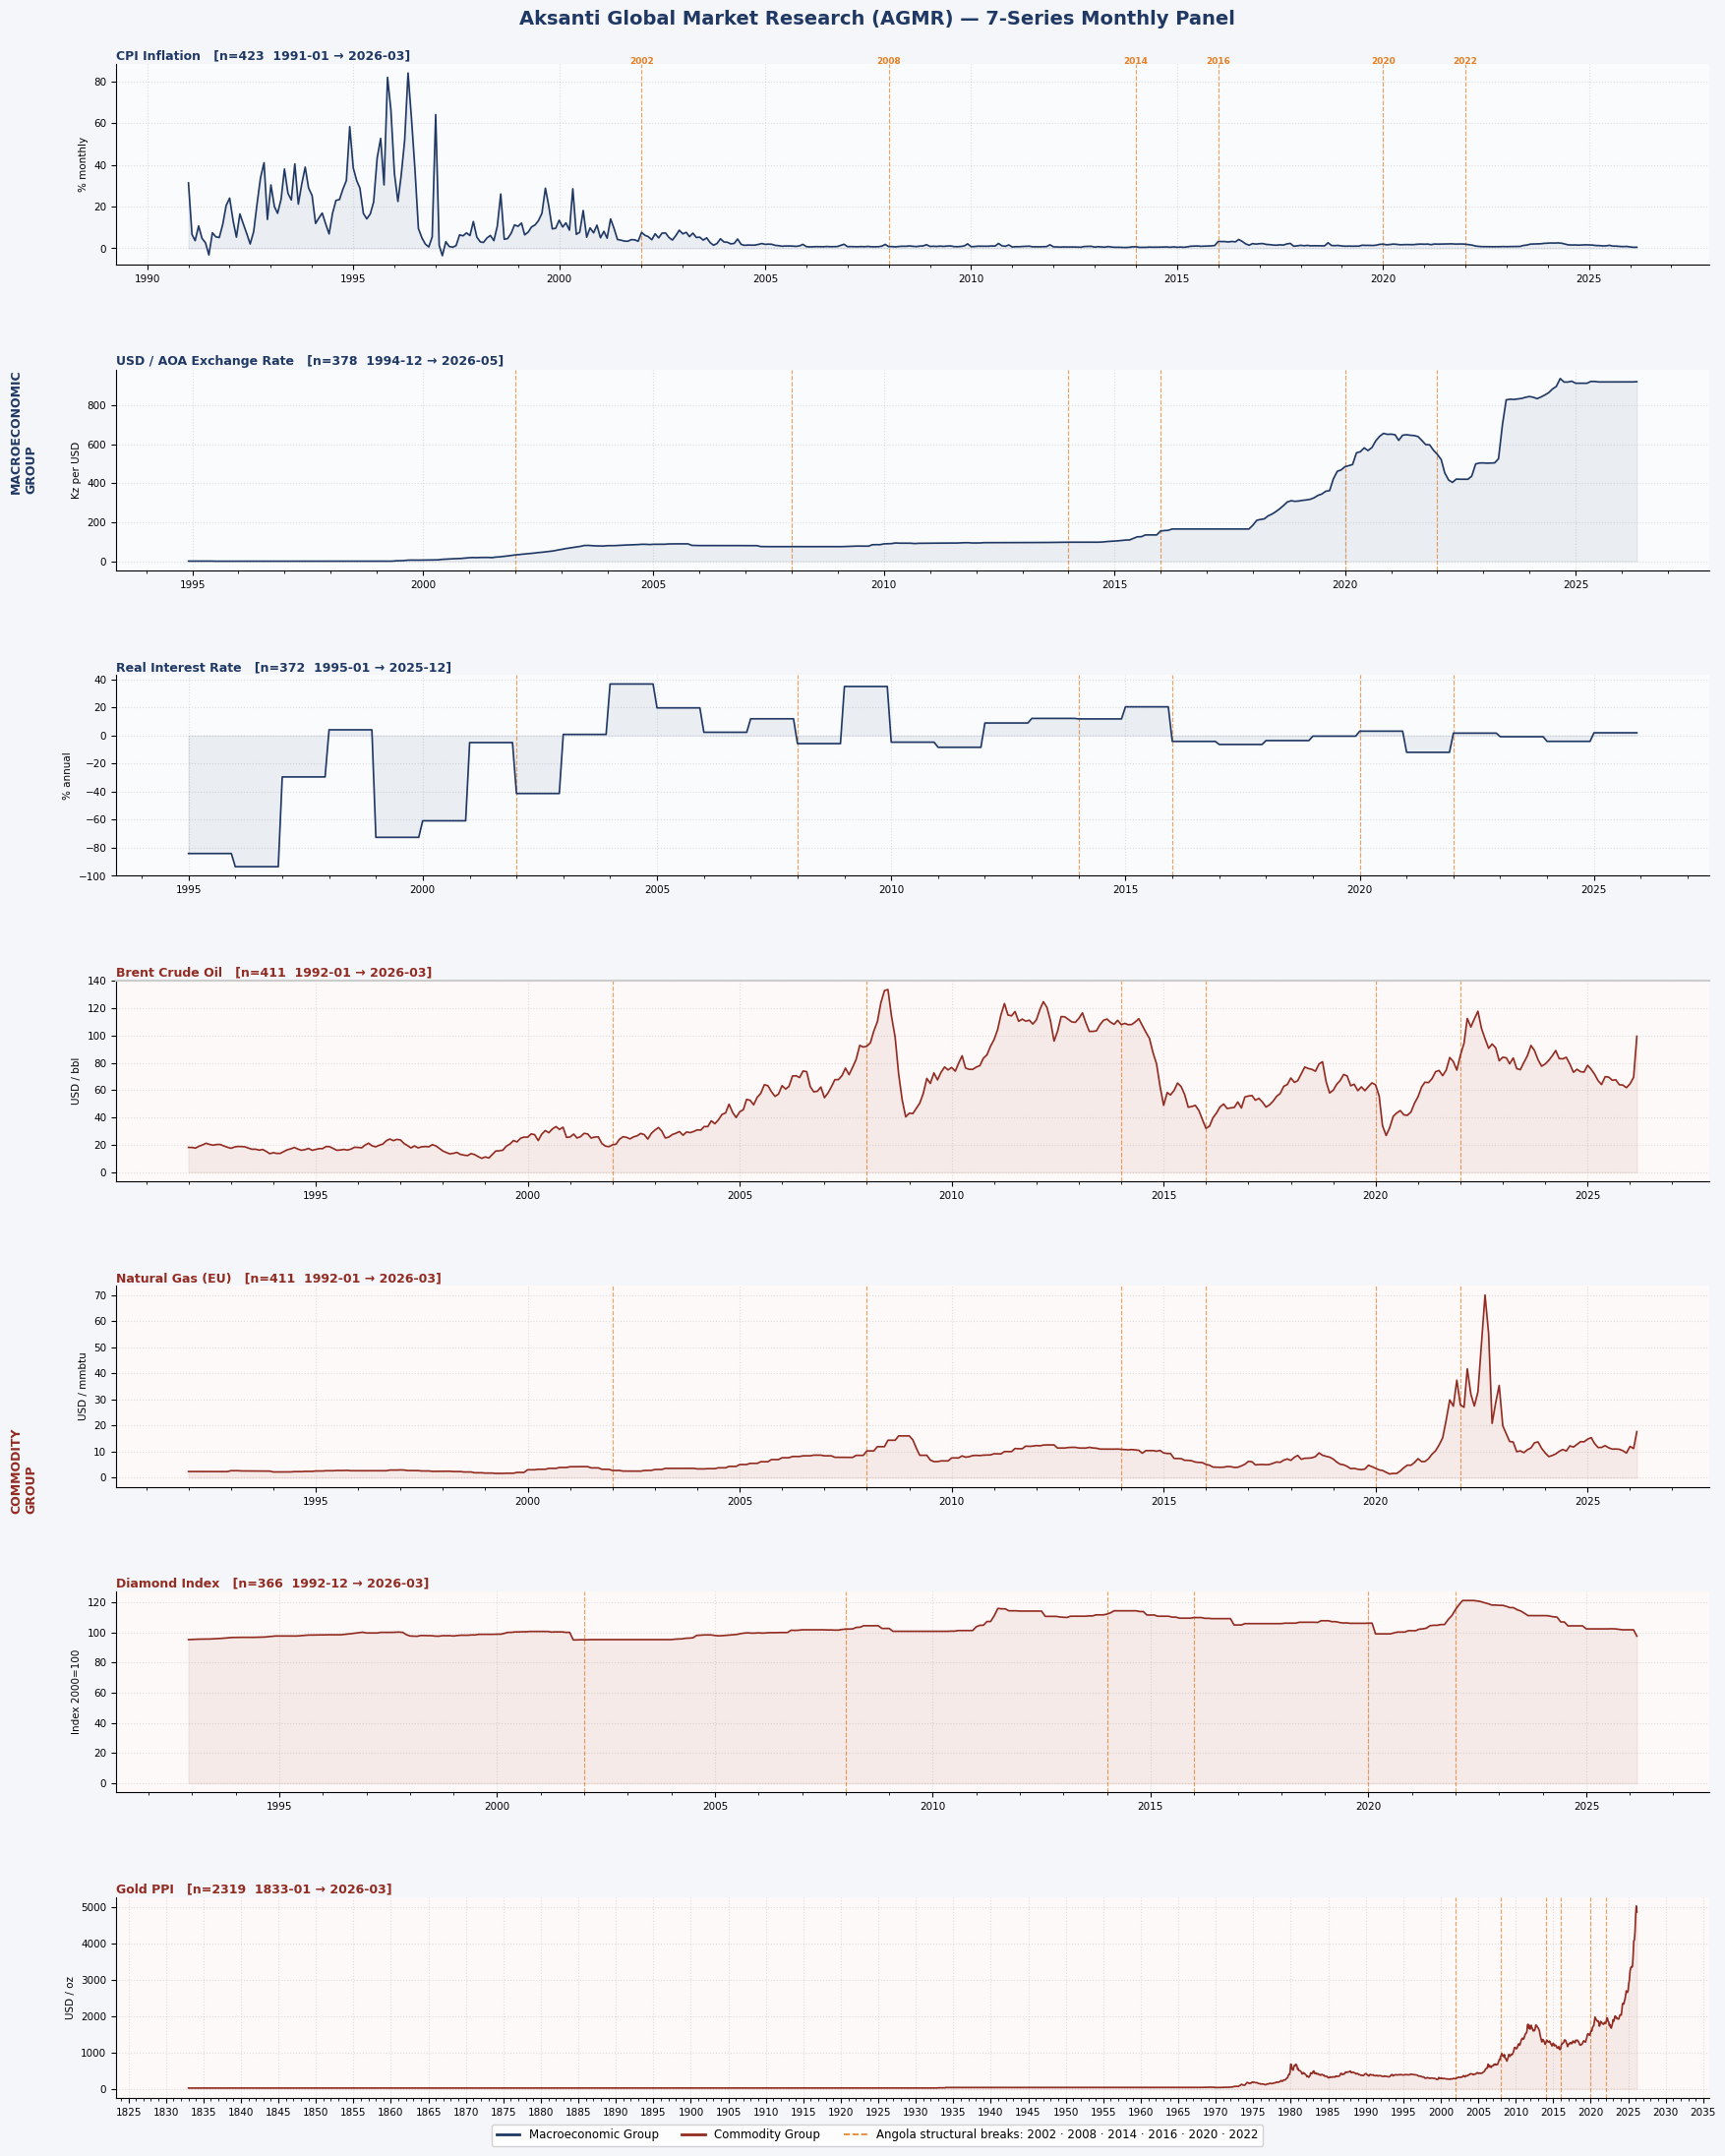

Figure 3 saved → /content/drive/MyDrive/AGMR/outputs/figures/fig3_agmr_dashboard.png


In [102]:
# Figure 3 — Full 7-series Dashboard

import matplotlib.gridspec as gridspec

fig3 = plt.figure(figsize=(18, 22), facecolor='#F5F6FA')

# Title block
fig3.text(
    0.5, 0.995,
    'Aksanti Global Market Research (AGMR) — 7-Series Monthly Panel',
    ha='center', va='top', fontsize=14, fontweight='bold', color='#1F3864'
)

# Group labels on left margin
fig3.text(0.01, 0.80, 'MACROECONOMIC\nGROUP',
          ha='left', va='center', fontsize=9, fontweight='bold',
          color=C_MACRO, rotation=90)
fig3.text(0.01, 0.32, 'COMMODITY\nGROUP',
          ha='left', va='center', fontsize=9, fontweight='bold',
          color=C_COMMODITY, rotation=90)

# GridSpec: 7 rows, 1 column, varying heights
gs = gridspec.GridSpec(
    7, 1, figure=fig3,
    hspace=0.52,
    left=0.07, right=0.97, top=0.97, bottom=0.03
)

for i, (col, label, unit, grp, color) in enumerate(SERIES):
    ax = fig3.add_subplot(gs[i])
    sub = panel[['date', col]].dropna()

    bg = '#FAFBFD' if grp == 'macro' else '#FDF9F8'
    ax.set_facecolor(bg)
    ax.plot(sub['date'], sub[col], color=color, linewidth=1.2, zorder=3)
    ax.fill_between(sub['date'], sub[col], alpha=C_FILL, color=color, zorder=2)

    # Group divider line above first commodity series
    if i == 3:
        ax.spines['top'].set_visible(True)
        ax.spines['top'].set_linewidth(1.5)
        ax.spines['top'].set_color('#CCCCCC')

    ax.set_ylabel(unit, fontsize=7.5, labelpad=4)
    ax.set_title(
        f'{label}   '
        f'[n={len(sub)}  {sub["date"].min().strftime("%Y-%m")} → {sub["date"].max().strftime("%Y-%m")}]',
        fontsize=9, fontweight='bold', color=color, loc='left', pad=3
    )

    fmt_xaxis(ax)
    ax.tick_params(axis='y', labelsize=7.5)
    ax.tick_params(axis='x', labelsize=7.5)

    # Break lines
    ymin, ymax = sub[col].min(), sub[col].max()
    yrange = ymax - ymin if ymax != ymin else 1
    for j, bd in enumerate(BREAK_DATES):
        ax.axvline(bd, color=C_BREAK, linewidth=0.85, linestyle='--', alpha=0.7, zorder=1)
        if i == 0:   # only label break years on top subplot
            ax.text(bd, ymax + yrange * 0.04, str(BREAKS[j]),
                    fontsize=6.5, color=C_BREAK, ha='center', va='bottom', fontweight='bold')

# Shared legend at the bottom
legend_elements = [
    Line2D([0], [0], color=C_MACRO,     linewidth=2, label='Macroeconomic Group'),
    Line2D([0], [0], color=C_COMMODITY, linewidth=2, label='Commodity Group'),
    Line2D([0], [0], color=C_BREAK,     linewidth=1.2, linestyle='--',
           label='Angola structural breaks: 2002 · 2008 · 2014 · 2016 · 2020 · 2022'),
]
fig3.legend(
    handles=legend_elements,
    loc='lower center', ncol=3,
    fontsize=8.5, framealpha=0.85, edgecolor='#CCCCCC',
    bbox_to_anchor=(0.5, 0.005)
)

path3 = os.path.join(OUTPUT_DIR, 'fig3_agmr_dashboard.png')
fig3.savefig(path3, dpi=180, bbox_inches='tight', facecolor=fig3.get_facecolor())
plt.show()
print(f"Figure 3 saved → {path3}")

In [103]:
# Create a subset of panel data for the period 1995-2025

start_date = '1995-01-01'
end_date = '2025-12-31'

panel_subset = panel[(panel['date'] >= start_date) & (panel['date'] <= end_date)].copy()

print("\n══════════════════════════════════════════════════════════════")
print("PANEL SUBSET (1995-2025) — SUMMARY")
print("══════════════════════════════════════════════════════════════")
print(f"  Total rows    : {len(panel_subset)}")
print(f"  Date range    : {panel_subset['date'].min().strftime('%Y-%m')} → {panel_subset['date'].max().strftime('%Y-%m')}")
print("\n  First 5 rows of panel_subset:")
print(panel_subset.head(5).to_string(index=False))
print("\n  Last 5 rows of panel_subset:")
print(panel_subset.tail(5).to_string(index=False))


══════════════════════════════════════════════════════════════
PANEL SUBSET (1995-2025) — SUMMARY
══════════════════════════════════════════════════════════════
  Total rows    : 372
  Date range    : 1995-01 → 2025-12

  First 5 rows of panel_subset:
      date  cpi_inflation_pct  usd_aoa_monthly  real_interest_rate_monthly  oil_brent_usd_bbl  nat_gas_usd_mmbtu  diamond_usd_carat  gold_usd
1995-01-01            38.6000           0.5246                    -84.0950            16.6541             2.5900                NaN  378.5500
1995-02-01            32.4200           0.5514                    -84.0950            17.2710             2.5900                NaN  376.6400
1995-03-01            28.9100           0.5825                    -84.0950            17.2365             2.5900            97.6000  382.1200
1995-04-01            16.7600           0.6213                    -84.0950            18.8240             2.6900                NaN  391.0300
1995-05-01            14.1500        

In [104]:
print("\n══════════════════════════════════════════════════════════════")
print("MISSING DATA CHECK IN PANEL SUBSET (1995-2025)")
print("══════════════════════════════════════════════════════════════")

# Display NaN counts for all columns in the subset
missing_data_in_subset = panel_subset.isnull().sum()
print("Total NaN values per column in panel_subset:")
print(missing_data_in_subset[missing_data_in_subset > 0])

if (missing_data_in_subset == 0).all():
    print("\nThere are no missing values in the panel_subset.")
else:
    print("\nSome missing values still remain in the listed columns of panel_subset. Further treatment may be needed.")


══════════════════════════════════════════════════════════════
MISSING DATA CHECK IN PANEL SUBSET (1995-2025)
══════════════════════════════════════════════════════════════
Total NaN values per column in panel_subset:
diamond_usd_carat    18
dtype: int64

Some missing values still remain in the listed columns of panel_subset. Further treatment may be needed.


In [105]:
# Imputing missing data in 'diamond_usd_carat' using a 5-month rolling median

print("\n══════════════════════════════════════════════════════════════")
print("IMPUTING 'diamond_usd_carat' IN PANEL SUBSET WITH ROLLING MEDIAN")
print("══════════════════════════════════════════════════════════════")

# Store initial NaN count for 'diamond_usd_carat'
initial_nan_diamond = panel_subset['diamond_usd_carat'].isnull().sum()
print(f"Initial NaN count for 'diamond_usd_carat': {initial_nan_diamond}")

# Calculate rolling median (5-month window, centered, min_periods=1 for early values)
rolling_median_diamond = panel_subset['diamond_usd_carat'].rolling(window=5, min_periods=1, center=True).median()

# Fill NaN values with the calculated rolling median
panel_subset['diamond_usd_carat'] = panel_subset['diamond_usd_carat'].fillna(rolling_median_diamond)

# Check NaN count after imputation
final_nan_diamond = panel_subset['diamond_usd_carat'].isnull().sum()
print(f"Final NaN count for 'diamond_usd_carat' after rolling median: {final_nan_diamond}")

if final_nan_diamond == 0:
    print("All missing values in 'diamond_usd_carat' have been imputed.")
else:
    print(f"Warning: {final_nan_diamond} NaNs still remain in 'diamond_usd_carat'. Further treatment might be needed.")




══════════════════════════════════════════════════════════════
IMPUTING 'diamond_usd_carat' IN PANEL SUBSET WITH ROLLING MEDIAN
══════════════════════════════════════════════════════════════
Initial NaN count for 'diamond_usd_carat': 18
Final NaN count for 'diamond_usd_carat' after rolling median: 0
All missing values in 'diamond_usd_carat' have been imputed.


In [106]:
print("\n══════════════════════════════════════════════════════════════")
print("FINAL MISSING DATA CHECK IN PANEL SUBSET (1995-2025)")
print("══════════════════════════════════════════════════════════════")

# Display NaN counts for all columns in the subset
final_missing_data_check = panel_subset.isnull().sum()
print("Total NaN values per column in panel_subset:")
print(final_missing_data_check[final_missing_data_check > 0])

if (final_missing_data_check == 0).all():
    print("\nAll missing values in the panel_subset have been imputed.")
else:
    print("\nWarning: Some missing values still remain in the listed columns of panel_subset. Further treatment may be needed.")


══════════════════════════════════════════════════════════════
FINAL MISSING DATA CHECK IN PANEL SUBSET (1995-2025)
══════════════════════════════════════════════════════════════
Total NaN values per column in panel_subset:
Series([], dtype: int64)

All missing values in the panel_subset have been imputed.


In [107]:
print("\n══════════════════════════════════════════════════════════════")
print("OUTLIER DETECTION IN PANEL SUBSET (1995-2025)")
print("══════════════════════════════════════════════════════════════")

# Exclude the 'date' column as it's not numerical for outlier detection
numerical_cols = panel_subset.select_dtypes(include=np.number).columns.tolist()

outliers_summary = {}

for col in numerical_cols:
    Q1 = panel_subset[col].quantile(0.25)
    Q3 = panel_subset[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = panel_subset[(panel_subset[col] < lower_bound) | (panel_subset[col] > upper_bound)]
    outliers_summary[col] = len(outliers)

    if len(outliers) > 0:
        print(f"Column '{col}': {len(outliers)} outliers detected.")
    else:
        print(f"Column '{col}': No outliers detected.")

print("\nOutlier summary (count of outliers per column):")
for col, count in outliers_summary.items():
    print(f"  {col:<30}: {count} outliers")



══════════════════════════════════════════════════════════════
OUTLIER DETECTION IN PANEL SUBSET (1995-2025)
══════════════════════════════════════════════════════════════
Column 'cpi_inflation_pct': 48 outliers detected.
Column 'usd_aoa_monthly': 65 outliers detected.
Column 'real_interest_rate_monthly': 84 outliers detected.
Column 'oil_brent_usd_bbl': No outliers detected.
Column 'nat_gas_usd_mmbtu': 15 outliers detected.
Column 'diamond_usd_carat': No outliers detected.
Column 'gold_usd': 8 outliers detected.

Outlier summary (count of outliers per column):
  cpi_inflation_pct             : 48 outliers
  usd_aoa_monthly               : 65 outliers
  real_interest_rate_monthly    : 84 outliers
  oil_brent_usd_bbl             : 0 outliers
  nat_gas_usd_mmbtu             : 15 outliers
  diamond_usd_carat             : 0 outliers
  gold_usd                      : 8 outliers


There are few outliers in the data. But, since we are dealing with timeseires the outliers will be considered in the analysis without being imputed. Meaning, they are real data points.

# Exploratory Data Analysis (EDA)

* Missing data detection
* Define panel_subset and descriptive statistics
* Time-series plots with structural break markers
* Distribution plots (histogram + KDE per series)
* Box plots by structural break regime
* Rolling statistics (12-month rolling mean and std)
* Within-group cross-correlation heatmaps
* ACF and PACF plots
* Stationarity tests (ADF + KPSS)   
* EDA summary table



In [108]:
# Series metadata
# (column, display label, y-axis unit, group)
SERIES = [
    ('cpi_inflation_pct',          'CPI Inflation',          '% monthly',     'Macroeconomic'),
    ('usd_aoa_monthly',            'USD/AOA Exchange Rate',  'Kz per USD',    'Macroeconomic'),
    ('real_interest_rate_monthly', 'Real Interest Rate',     '% annual',      'Macroeconomic'),
    ('oil_brent_usd_bbl',          'Brent Crude Oil',        'USD/bbl',       'Commodity'),
    ('nat_gas_usd_mmbtu',          'Natural Gas (EU)',        'USD/mmbtu',     'Commodity'),
    ('diamond_usd_carat',          'Diamond Index',          'Index 2000=100','Commodity'),
    ('gold_usd',                   'Gold PPI',               'USD/oz',        'Commodity'),
]
COLS   = [s[0] for s in SERIES]
LABELS = {s[0]: s[1] for s in SERIES}
UNITS  = {s[0]: s[2] for s in SERIES}
GROUPS = {s[0]: s[3] for s in SERIES}

C_MACRO     = '#1F3864'
C_COMMODITY = '#922B21'
C_BREAK     = '#E67E22'
C_ALT       = '#EBF3FB'

COLOR = {c: (C_MACRO if GROUPS[c] == 'Macroeconomic' else C_COMMODITY) for c in COLS}

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.linestyle'    : ':',
    'grid.alpha'        : 0.35,
    'axes.titlesize'    : 10,
    'axes.labelsize'    : 9,
    'xtick.labelsize'   : 8,
    'ytick.labelsize'   : 8,
})

print("Configuration loaded ✓")


Configuration loaded ✓


In [109]:

# Descriptive statistics table ────────────────────────────────────

desc_rows = []
for col in COLS:
    s = panel_subset[col].dropna()
    desc_rows.append({
        'Series'     : LABELS[col],
        'Group'      : GROUPS[col],
        'N'          : len(s),
        'NaN'        : panel_subset[col].isna().sum(),
        'Mean'       : round(s.mean(), 4),
        'Std'        : round(s.std(), 4),
        'Min'        : round(s.min(), 4),
        'Q1'         : round(s.quantile(0.25), 4),
        'Median'     : round(s.median(), 4),
        'Q3'         : round(s.quantile(0.75), 4),
        'Max'        : round(s.max(), 4),
        'Skewness'   : round(s.skew(), 4),
        'Kurtosis'   : round(s.kurtosis(), 4),
    })

desc_df = pd.DataFrame(desc_rows).set_index('Series')
print("=" * 80)
print("DESCRIPTIVE STATISTICS — panel_subset")
print("=" * 80)
print(desc_df.to_string())

DESCRIPTIVE STATISTICS — panel_subset
                               Group    N  NaN      Mean      Std      Min       Q1    Median        Q3       Max  Skewness  Kurtosis
Series                                                                                                                               
CPI Inflation          Macroeconomic  372    0    4.9781  10.6941  -3.5200   0.9300    1.5950    3.7625   84.0900    4.5957   24.2764
USD/AOA Exchange Rate  Macroeconomic  372    0  203.3438 261.8633   0.0022  49.7497   92.0485  214.5619  936.2920    1.6215    1.3962
Real Interest Rate     Macroeconomic  372    0   -8.6144  30.8186 -93.5135  -8.3980   -0.8551    8.9104   36.7004   -1.3620    1.3410
Brent Crude Oil            Commodity  372    0   59.0412  31.4564  10.1600  28.3575   59.6247   79.2363  133.5852    0.2755   -0.9486
Natural Gas (EU)           Commodity  372    0    8.0059   7.4177   1.4626   3.3223    6.6542   10.4000   69.9772    3.8581   22.0440
Diamond Index           

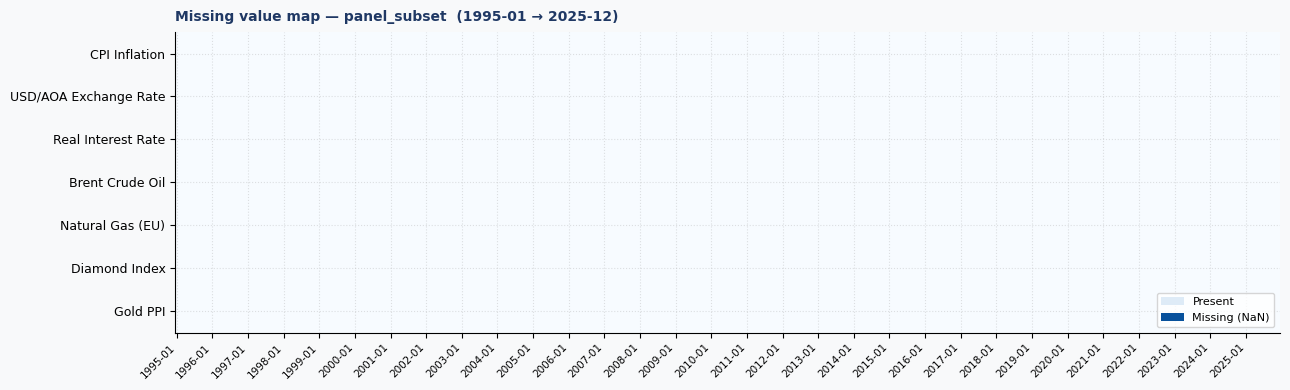

Saved → /content/drive/MyDrive/AGMR/outputs/figures/eda_01_missing_value_map.png

Missing values in panel_subset:
  CPI Inflation                   NaN =   0  (0.0%)
  USD/AOA Exchange Rate           NaN =   0  (0.0%)
  Real Interest Rate              NaN =   0  (0.0%)
  Brent Crude Oil                 NaN =   0  (0.0%)
  Natural Gas (EU)                NaN =   0  (0.0%)
  Diamond Index                   NaN =   0  (0.0%)
  Gold PPI                        NaN =   0  (0.0%)


In [110]:
# Missing values analysis

fig, ax = plt.subplots(figsize=(13, 4), facecolor='#F8F9FA')
ax.set_facecolor('#FAFBFC')

nan_matrix = panel_subset[COLS].isna().T.astype(int)
nan_matrix.index = [LABELS[c] for c in COLS]

im = ax.imshow(nan_matrix.values, aspect='auto', cmap='Blues',
               vmin=0, vmax=1, interpolation='none')

ax.set_yticks(range(len(COLS)))
ax.set_yticklabels(nan_matrix.index, fontsize=9)

# x-axis: sample every 12 months
step = 12
xtick_pos  = list(range(0, len(panel_subset), step))
xtick_lbls = [panel_subset['date'].iloc[i].strftime('%Y-%m') for i in xtick_pos]
ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_lbls, rotation=45, ha='right', fontsize=7.5)

ax.set_title(
    f'Missing value map — panel_subset  '
    f'({panel_subset["date"].min().strftime("%Y-%m")} → {panel_subset["date"].max().strftime("%Y-%m")})',
    fontsize=10, fontweight='bold', color='#1F3864', loc='left', pad=8
)

legend_elements = [
    Patch(facecolor='#DEEBF7', label='Present'),
    Patch(facecolor='#08519C', label='Missing (NaN)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
          framealpha=0.8, edgecolor='#CCCCCC')

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'eda_01_missing_value_map.png')
fig.savefig(path, dpi=180, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"Saved → {path}")

# Summary
print("\nMissing values in panel_subset:")
for col in COLS:
    n = panel_subset[col].isna().sum()
    pct = 100 * n / len(panel_subset)
    print(f"  {LABELS[col]:<30}  NaN = {n:3d}  ({pct:.1f}%)")

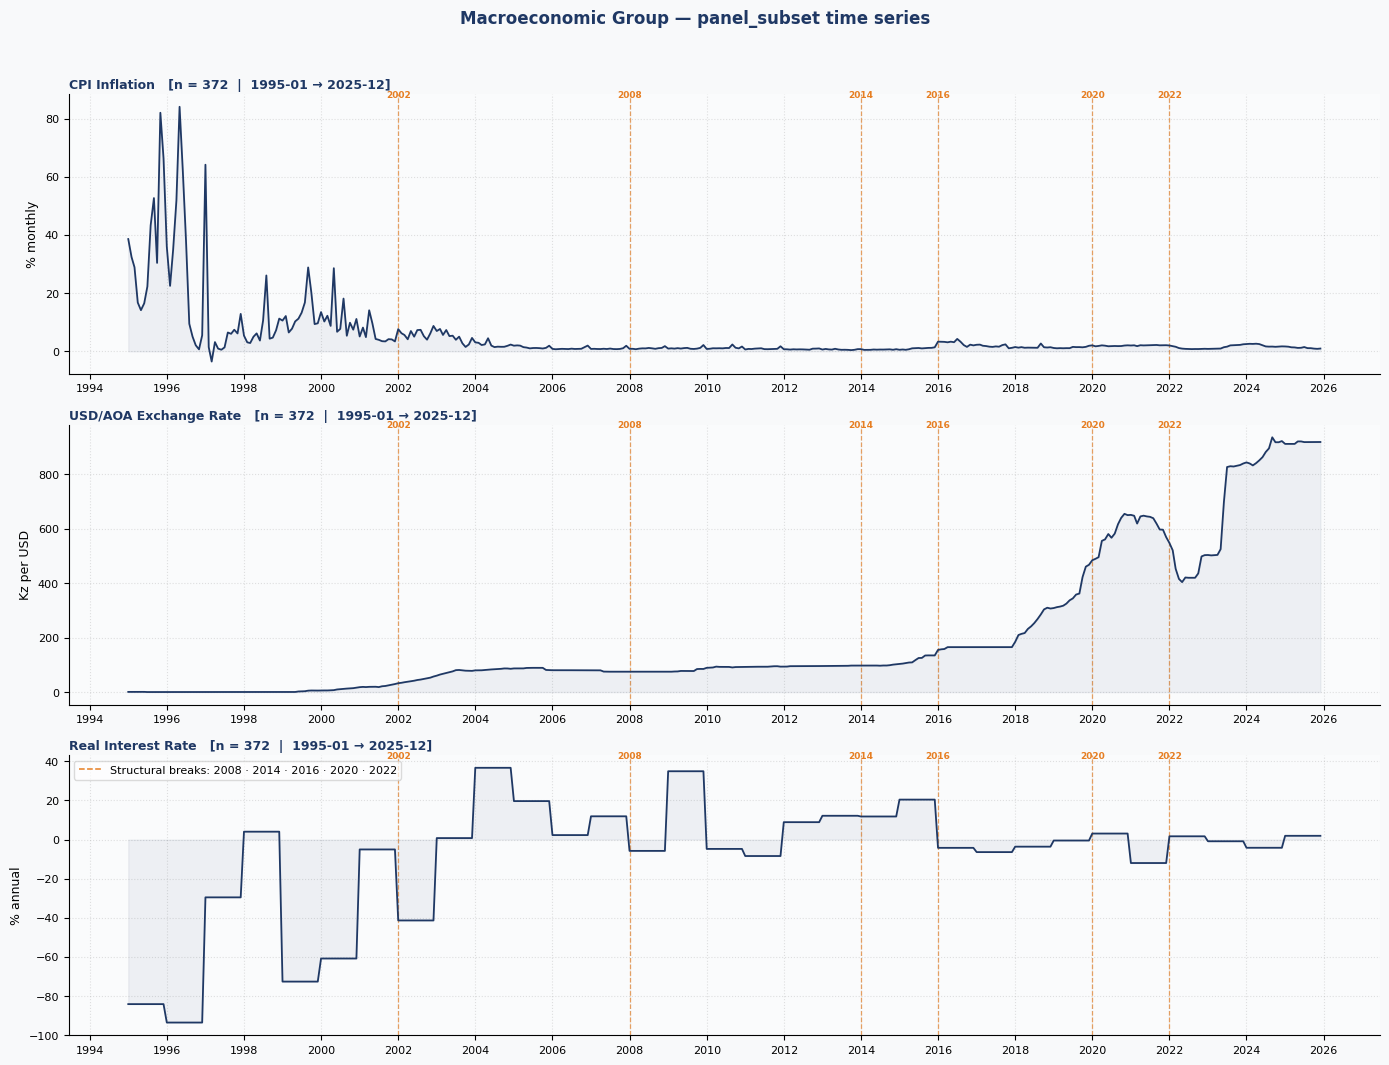

Saved → /content/drive/MyDrive/AGMR/outputs/figures/eda_02_macro_timeseries.png


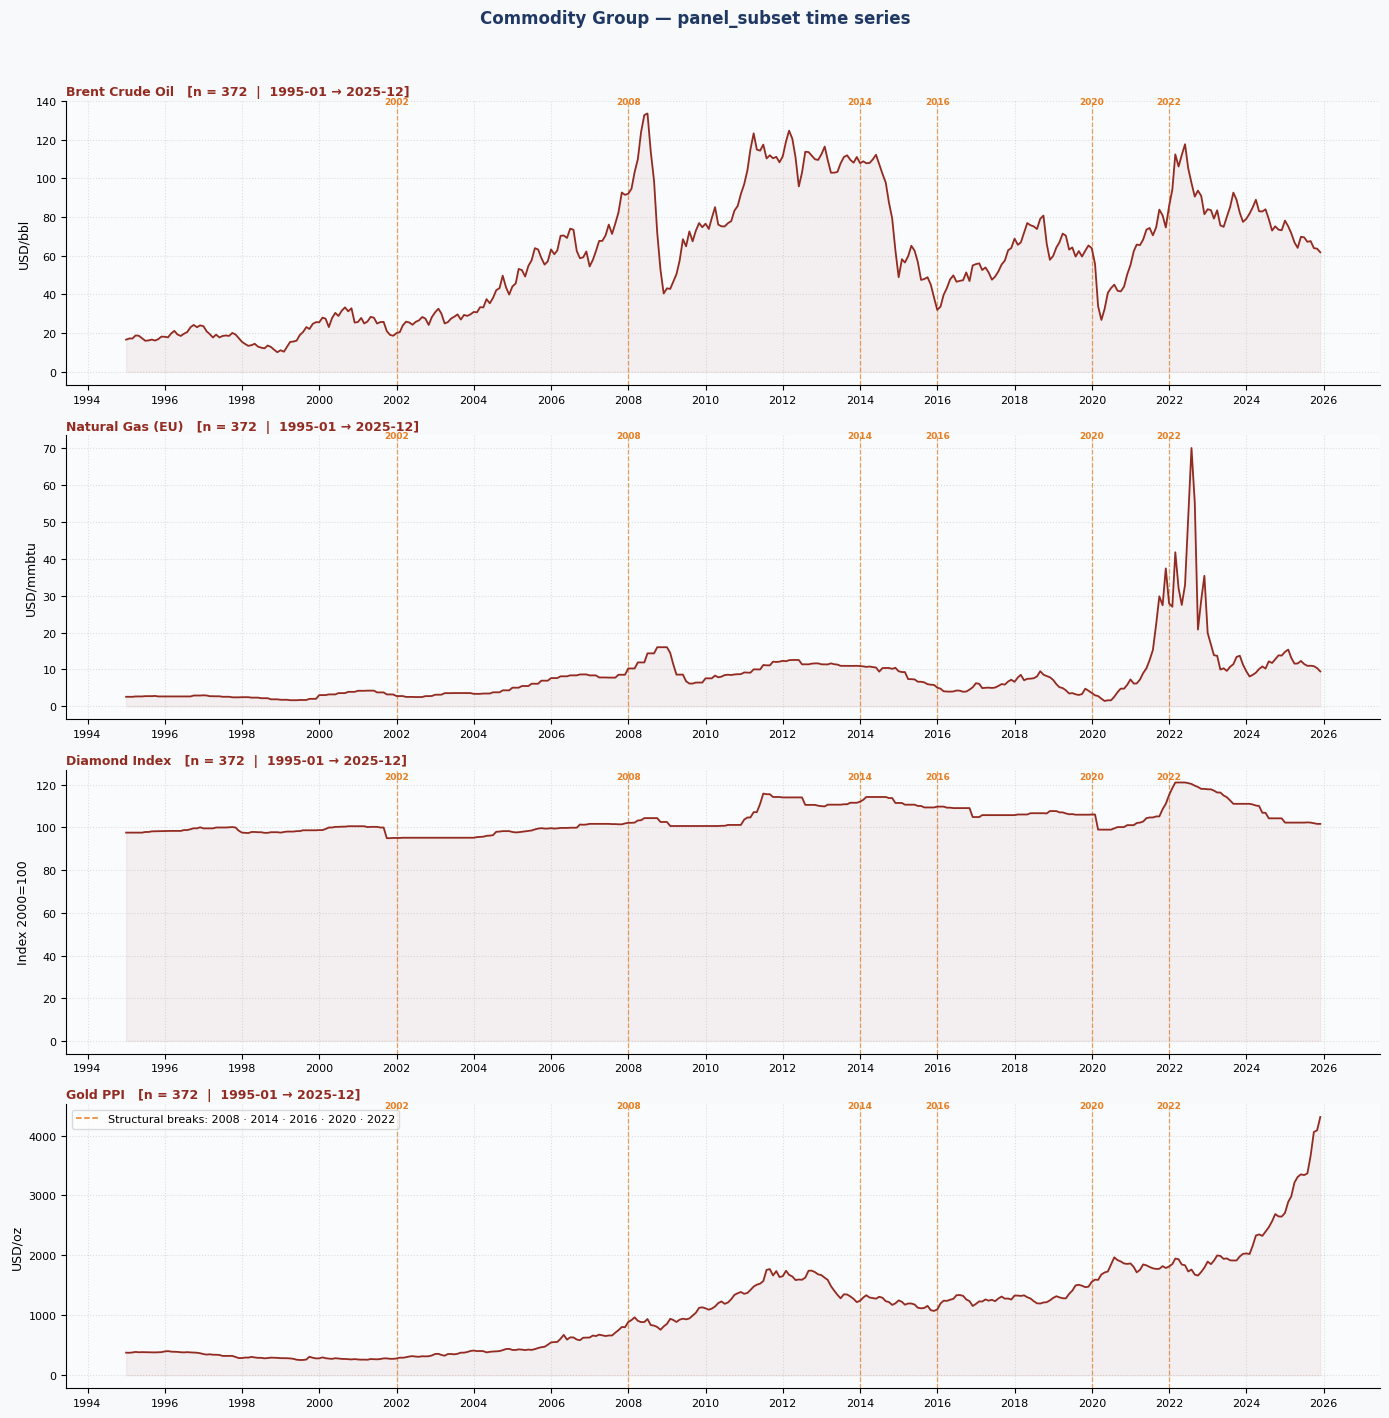

Saved → /content/drive/MyDrive/AGMR/outputs/figures/eda_03_commodity_timeseries.png


In [111]:

# Time-series plots

def plot_group(series_list, title, fname, bg='#F8F9FA'):
    n = len(series_list)
    fig, axes = plt.subplots(n, 1, figsize=(14, 3.5 * n), facecolor=bg)
    if n == 1: axes = [axes]
    fig.suptitle(title, fontsize=12, fontweight='bold',
                 color='#1F3864', y=1.01)

    for ax, (col, label, unit, grp) in zip(axes, series_list):
        sub = panel_subset[['date', col]].dropna()
        color = COLOR[col]

        ax.set_facecolor('#FAFBFC')
        ax.plot(sub['date'], sub[col], color=color, linewidth=1.3, zorder=3)
        ax.fill_between(sub['date'], sub[col], alpha=0.06, color=color, zorder=2)

        ymin, ymax = sub[col].min(), sub[col].max()
        yrange = ymax - ymin if ymax != ymin else 1

        for i, bd in enumerate(BREAK_DATES):
            ax.axvline(bd, color=C_BREAK, linewidth=0.9, linestyle='--',
                       alpha=0.75, zorder=1)
            if bd >= panel_subset['date'].min() and bd <= panel_subset['date'].max():
                ax.text(bd, ymax + yrange * 0.03, str(BREAKS[i]),
                        fontsize=6.5, color=C_BREAK, ha='center',
                        va='bottom', fontweight='bold')

        ax.set_ylabel(unit, fontsize=9)
        ax.set_title(
            f'{label}   '
            f'[n = {len(sub)}  |  '
            f'{sub["date"].min().strftime("%Y-%m")} → {sub["date"].max().strftime("%Y-%m")}]',
            fontsize=9, fontweight='bold', color=color, loc='left', pad=4
        )
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.setp(ax.get_xticklabels(), rotation=0, fontsize=8)

    legend_elements = [
        Line2D([0], [0], color=C_BREAK, linewidth=1.1, linestyle='--',
               label='Structural breaks: 2008 · 2014 · 2016 · 2020 · 2022')
    ]
    axes[-1].legend(handles=legend_elements, loc='upper left',
                    fontsize=8, framealpha=0.7, edgecolor='#CCCCCC')
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    path = os.path.join(OUTPUT_DIR, fname)
    fig.savefig(path, dpi=180, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f"Saved → {path}")

macro_series = [(col, lbl, unit, grp)
                for col, lbl, unit, grp in SERIES if grp == 'Macroeconomic']
comm_series  = [(col, lbl, unit, grp)
                for col, lbl, unit, grp in SERIES if grp == 'Commodity']

plot_group(
    macro_series,
    'Macroeconomic Group — panel_subset time series',
    'eda_02_macro_timeseries.png'
)
plot_group(
    comm_series,
    'Commodity Group — panel_subset time series',
    'eda_03_commodity_timeseries.png'
)

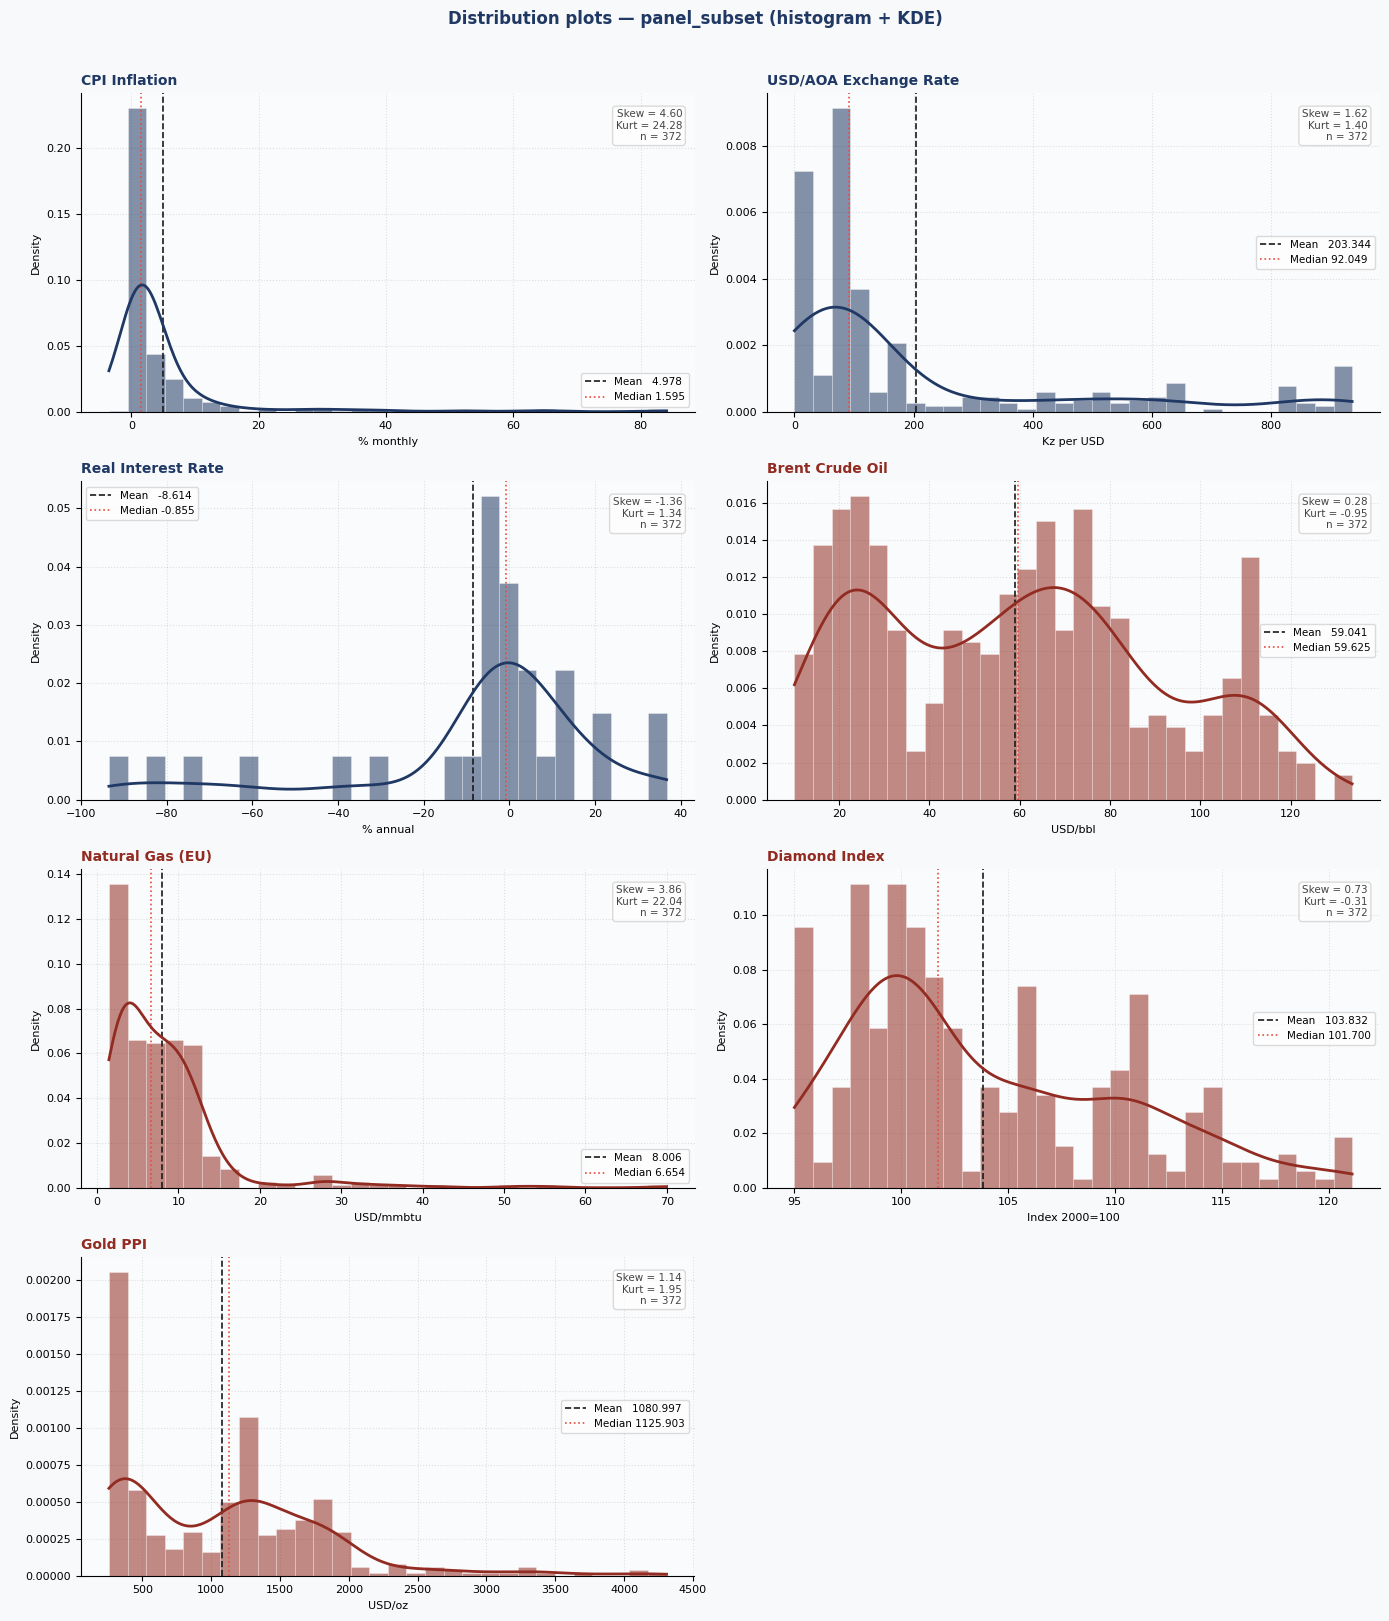

Saved → /content/drive/MyDrive/AGMR/outputs/figures/eda_04_distributions.png


In [112]:



# Distribution plots


# Histogram + KDE for each series

fig, axes = plt.subplots(4, 2, figsize=(14, 16), facecolor='#F8F9FA')
axes = axes.flatten()

for i, (col, label, unit, grp) in enumerate(SERIES):
    ax = axes[i]
    s = panel_subset[col].dropna()
    color = COLOR[col]

    ax.set_facecolor('#FAFBFC')

    # Histogram
    ax.hist(s, bins=30, color=color, alpha=0.55, density=True,
            edgecolor='white', linewidth=0.4, zorder=2)

    # KDE overlay
    kde_x = np.linspace(s.min(), s.max(), 300)
    kde   = stats.gaussian_kde(s)
    ax.plot(kde_x, kde(kde_x), color=color, linewidth=2.0, zorder=3)

    # Mean and median lines
    ax.axvline(s.mean(),   color='#1A1A1A', linewidth=1.2,
               linestyle='--', label=f'Mean   {s.mean():.3f}')
    ax.axvline(s.median(), color='#E74C3C', linewidth=1.2,
               linestyle=':',  label=f'Median {s.median():.3f}')

    ax.set_title(label, fontsize=10, fontweight='bold', color=color, loc='left')
    ax.set_xlabel(unit, fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=7.5, framealpha=0.7, edgecolor='#CCCCCC')
    ax.text(0.98, 0.95,
            f'Skew = {s.skew():.2f}\nKurt = {s.kurtosis():.2f}\nn = {len(s)}',
            transform=ax.transAxes, fontsize=7.5, va='top', ha='right',
            color='#444444', bbox=dict(boxstyle='round,pad=0.3',
                                       facecolor='white', alpha=0.7, edgecolor='#CCCCCC'))

# Hide the 8th subplot (7 series only)
axes[7].set_visible(False)

fig.suptitle('Distribution plots — panel_subset (histogram + KDE)',
             fontsize=12, fontweight='bold', color='#1F3864', y=1.01)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'eda_04_distributions.png')
fig.savefig(path, dpi=180, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"Saved → {path}")

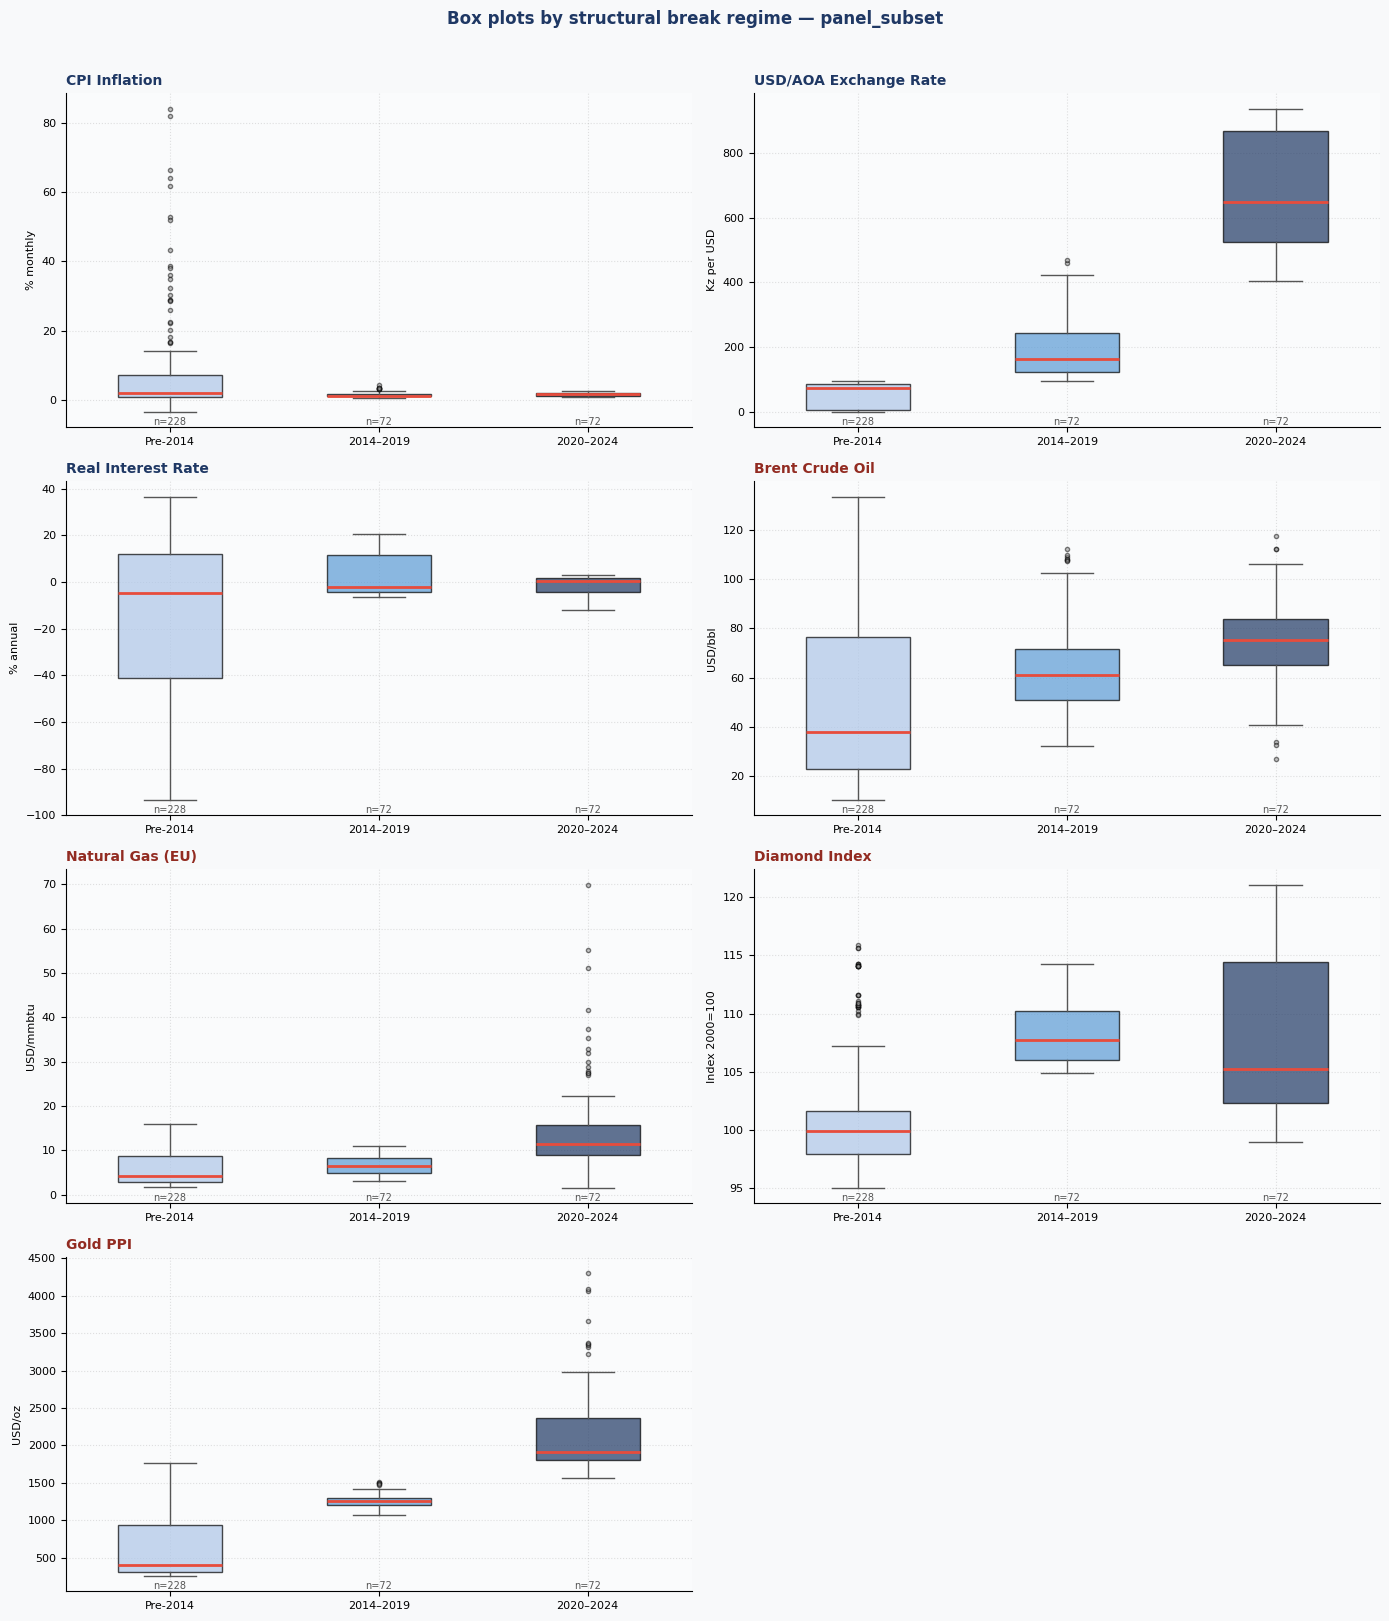

Saved → /content/drive/MyDrive/AGMR/outputs/figures/eda_05_boxplots_by_regime.png


In [113]:



# Box plots by structural break regime

# Assign each row to a regime based on the two most important break dates
def assign_regime(date):
    if date < pd.Timestamp('2014-01-01'):
        return 'Pre-2014'
    elif date < pd.Timestamp('2020-01-01'):
        return '2014–2019'
    else:
        return '2020–2024'

panel_subset['regime'] = panel_subset['date'].apply(assign_regime)
REGIME_ORDER  = ['Pre-2014', '2014–2019', '2020–2024']
REGIME_COLORS = ['#AEC6E8', '#5B9BD5', '#1F3864']

fig, axes = plt.subplots(4, 2, figsize=(14, 16), facecolor='#F8F9FA')
axes = axes.flatten()

for i, (col, label, unit, grp) in enumerate(SERIES):
    ax = axes[i]
    ax.set_facecolor('#FAFBFC')

    data_by_regime = [
        panel_subset.loc[panel_subset['regime'] == r, col].dropna().values
        for r in REGIME_ORDER
    ]

    bp = ax.boxplot(
        data_by_regime,
        labels=REGIME_ORDER,
        patch_artist=True,
        medianprops=dict(color='#E74C3C', linewidth=2),
        whiskerprops=dict(color='#555555', linewidth=1),
        capprops=dict(color='#555555', linewidth=1),
        flierprops=dict(marker='o', markerfacecolor='#999999',
                        markersize=3, linestyle='none', alpha=0.5),
        widths=0.5
    )
    for patch, color in zip(bp['boxes'], REGIME_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title(label, fontsize=10, fontweight='bold',
                 color=COLOR[col], loc='left')
    ax.set_ylabel(unit, fontsize=8)
    ax.tick_params(axis='x', labelsize=8)

    # Annotate n per regime
    for j, r in enumerate(REGIME_ORDER):
        n = panel_subset.loc[panel_subset['regime'] == r, col].notna().sum()
        ax.text(j + 1, ax.get_ylim()[0],
                f'n={n}', ha='center', va='bottom',
                fontsize=7, color='#555555')

axes[7].set_visible(False)

fig.suptitle('Box plots by structural break regime — panel_subset',
             fontsize=12, fontweight='bold', color='#1F3864', y=1.01)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'eda_05_boxplots_by_regime.png')
fig.savefig(path, dpi=180, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"Saved → {path}")

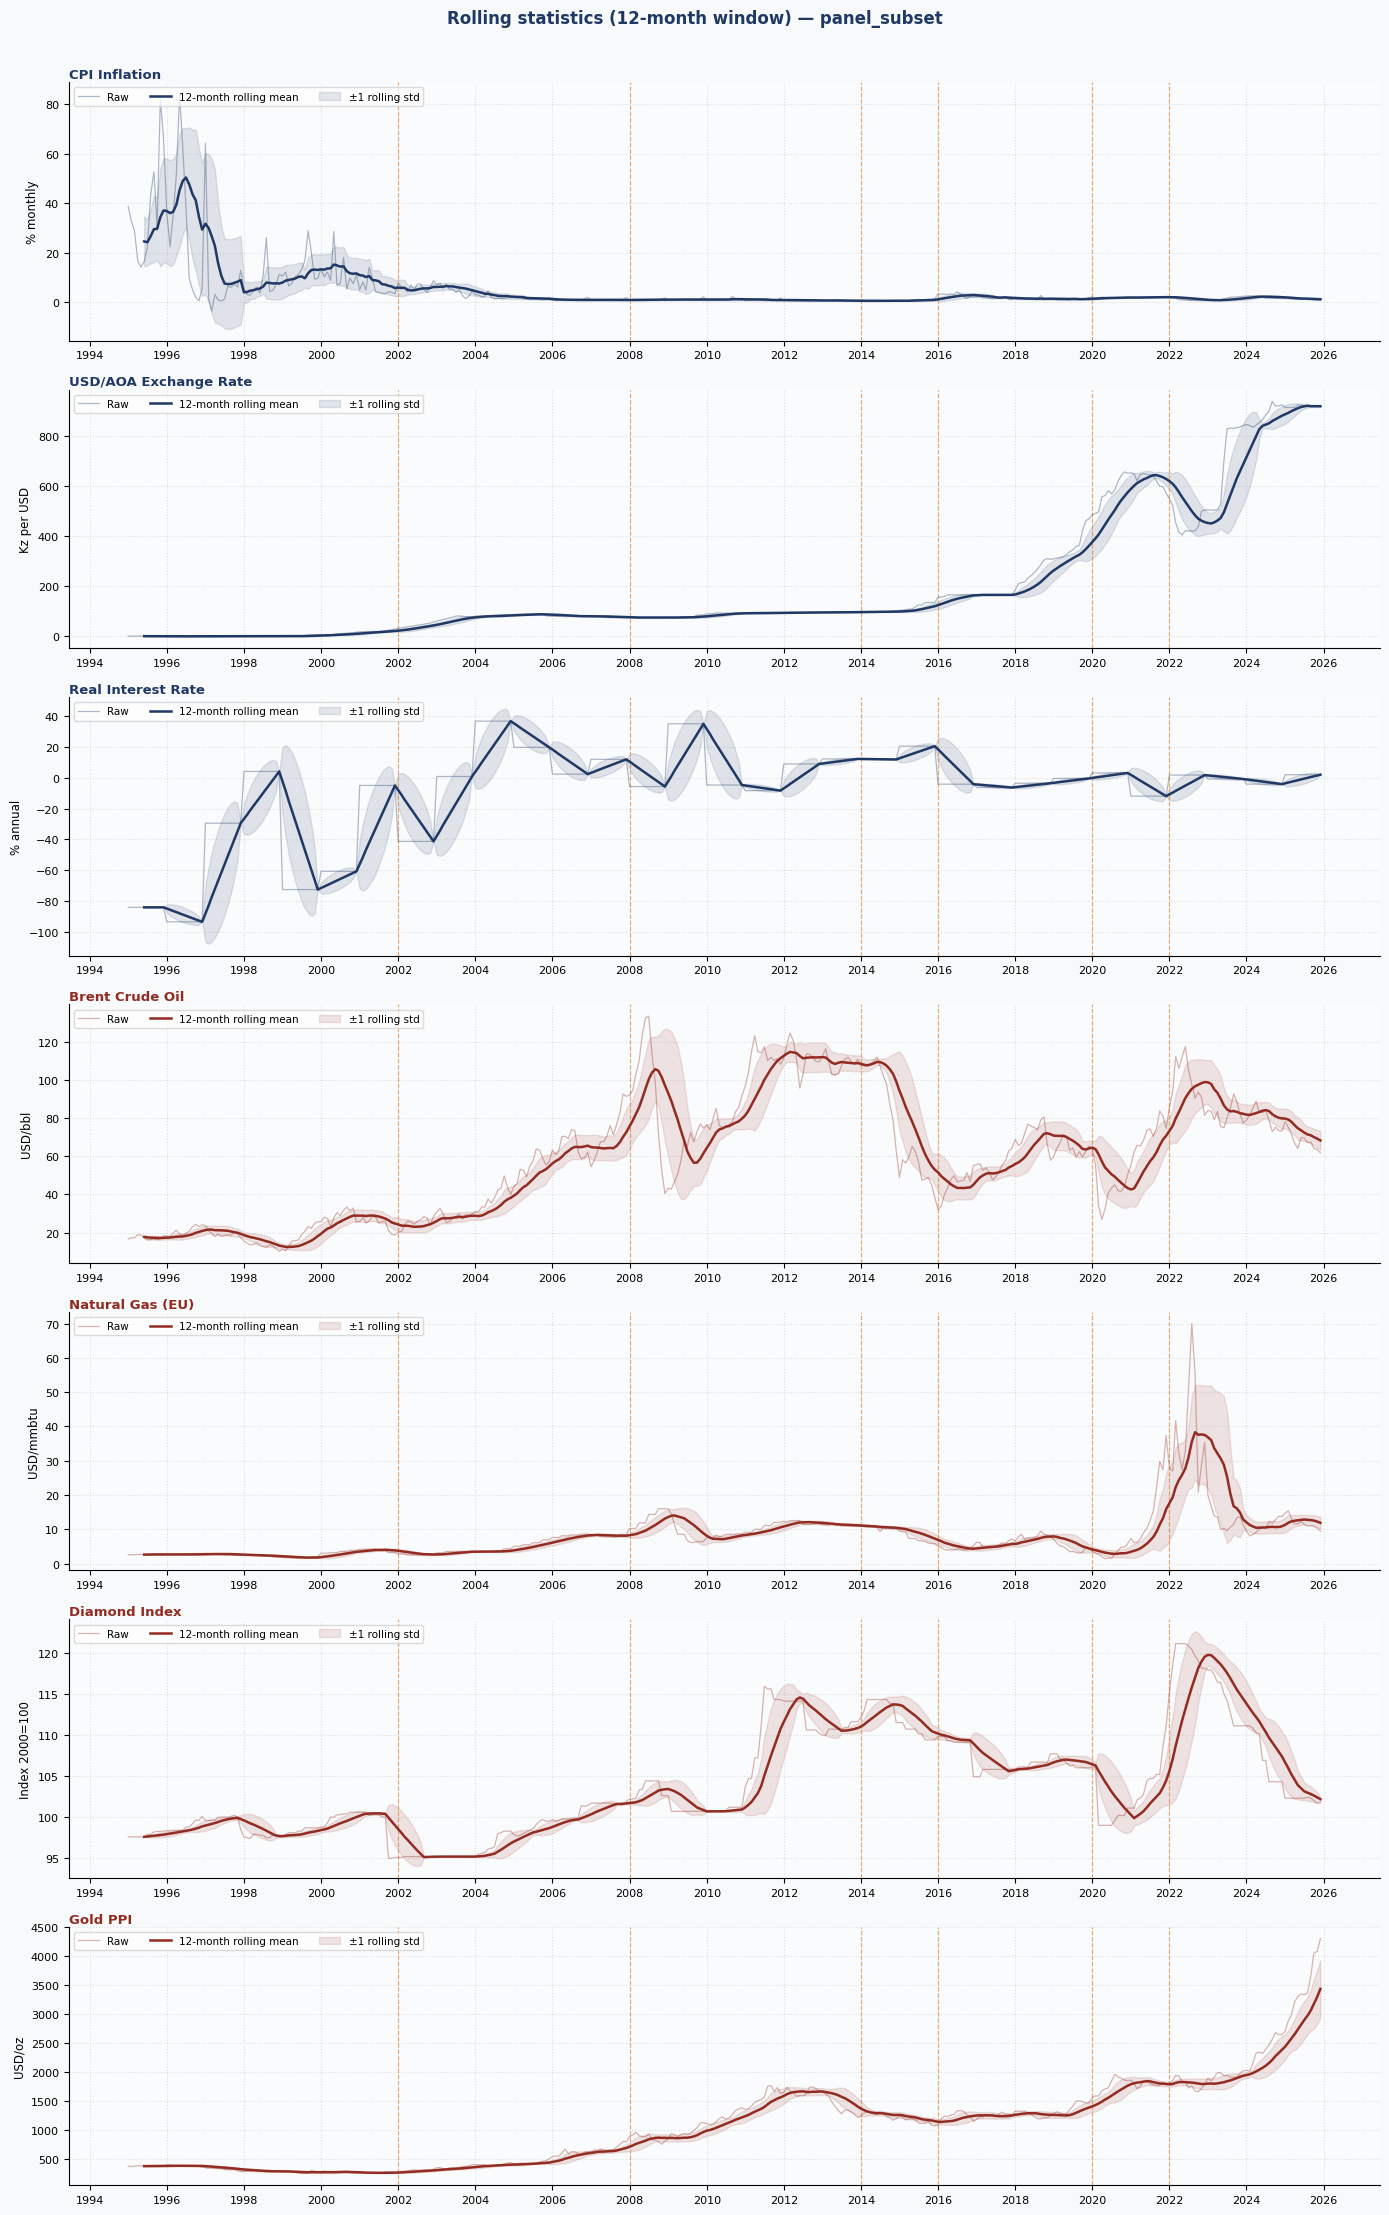

Saved → /content/drive/MyDrive/AGMR/outputs/figures/eda_06_rolling_statistics.png


In [114]:


# Rolling statistics


# 12-month rolling mean and rolling std

WINDOW = 12

fig, axes = plt.subplots(7, 1, figsize=(14, 22), facecolor='#F8F9FA')

for ax, (col, label, unit, grp) in zip(axes, SERIES):
    sub   = panel_subset[['date', col]].dropna().copy()
    roll_mean = sub[col].rolling(WINDOW, min_periods=6).mean()
    roll_std  = sub[col].rolling(WINDOW, min_periods=6).std()
    color = COLOR[col]

    ax.set_facecolor('#FAFBFC')

    # Raw series (light)
    ax.plot(sub['date'], sub[col],
            color=color, linewidth=0.9, alpha=0.35, label='Raw', zorder=2)

    # Rolling mean
    ax.plot(sub['date'], roll_mean,
            color=color, linewidth=1.8, label=f'{WINDOW}-month rolling mean', zorder=3)

    # Rolling ±1 std band
    ax.fill_between(
        sub['date'],
        roll_mean - roll_std,
        roll_mean + roll_std,
        alpha=0.12, color=color, label='±1 rolling std', zorder=1
    )

    # Break lines
    for bd in BREAK_DATES:
        ax.axvline(bd, color=C_BREAK, linewidth=0.85, linestyle='--',
                   alpha=0.65, zorder=1)

    ax.set_ylabel(unit, fontsize=8.5)
    ax.set_title(label, fontsize=9.5, fontweight='bold', color=color,
                 loc='left', pad=3)
    ax.legend(fontsize=7.5, framealpha=0.7, edgecolor='#CCCCCC',
              loc='upper left', ncol=3)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.get_xticklabels(), rotation=0, fontsize=8)

fig.suptitle(f'Rolling statistics ({WINDOW}-month window) — panel_subset',
             fontsize=12, fontweight='bold', color='#1F3864', y=1.005)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'eda_06_rolling_statistics.png')
fig.savefig(path, dpi=180, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f"Saved → {path}")

Macroeconomic Group — Correlation Matrix:


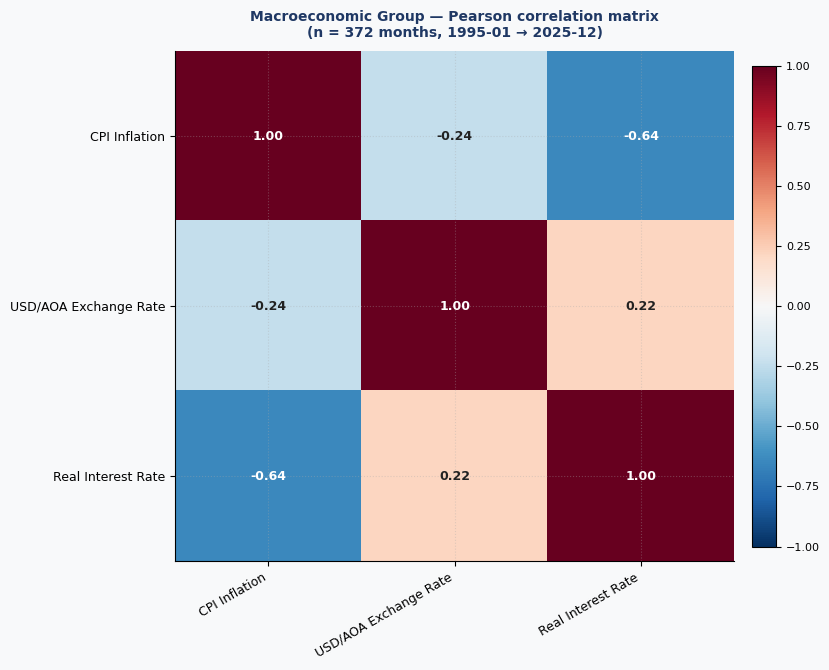

Saved → /content/drive/MyDrive/AGMR/outputs/figures/eda_07_corr_macro.png
                            cpi_inflation_pct  usd_aoa_monthly  real_interest_rate_monthly
cpi_inflation_pct                      1.0000          -0.2404                     -0.6444
usd_aoa_monthly                       -0.2404           1.0000                      0.2162
real_interest_rate_monthly            -0.6444           0.2162                      1.0000

Commodity Group — Correlation Matrix:


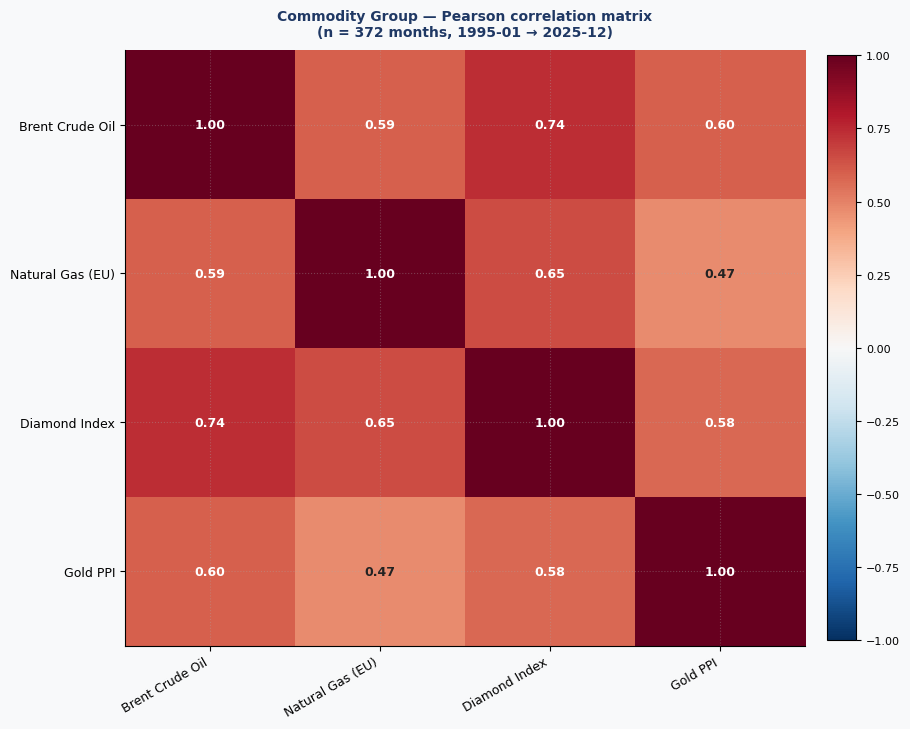

Saved → /content/drive/MyDrive/AGMR/outputs/figures/eda_08_corr_commodity.png
                   oil_brent_usd_bbl  nat_gas_usd_mmbtu  diamond_usd_carat  gold_usd
oil_brent_usd_bbl             1.0000             0.5945             0.7365    0.5983
nat_gas_usd_mmbtu             0.5945             1.0000             0.6509    0.4720
diamond_usd_carat             0.7365             0.6509             1.0000    0.5764
gold_usd                      0.5983             0.4720             0.5764    1.0000


In [115]:

# Within-group correlation heatmaps


def corr_heatmap(cols, group_name, color_map, fname):
    sub   = panel_subset[cols].dropna()
    corr  = sub.corr()
    lbls  = [LABELS[c] for c in cols]
    n     = len(cols)
    annot = corr.values

    fig2, ax = plt.subplots(figsize=(6 + n * 0.8, 5 + n * 0.6),
                            facecolor='#F8F9FA')
    im = ax.imshow(annot, cmap=color_map, vmin=-1, vmax=1, aspect='auto')

    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(lbls, fontsize=9, rotation=30, ha='right')
    ax.set_yticklabels(lbls, fontsize=9)

    for ii in range(n):
        for jj in range(n):
            v = annot[ii, jj]
            ax.text(jj, ii, f'{v:.2f}', ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color='white' if abs(v) > 0.5 else '#222222')

    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
    ax.set_title(
        f'{group_name} — Pearson correlation matrix\n'
        f'(n = {len(sub)} months, '
        f'{panel_subset.dropna(subset=cols)["date"].min().strftime("%Y-%m")} → '
        f'{panel_subset.dropna(subset=cols)["date"].max().strftime("%Y-%m")})',
        fontsize=10, fontweight='bold', color='#1F3864', pad=10
    )
    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, fname)
    fig2.savefig(path, dpi=180, bbox_inches='tight', facecolor=fig2.get_facecolor())
    plt.show()
    print(f"Saved → {path}")
    return corr

macro_cols = [col for col, _, _, grp in SERIES if grp == 'Macroeconomic']
comm_cols  = [col for col, _, _, grp in SERIES if grp == 'Commodity']

print("Macroeconomic Group — Correlation Matrix:")
corr_macro = corr_heatmap(macro_cols, 'Macroeconomic Group', 'RdBu_r',
                           'eda_07_corr_macro.png')
print(corr_macro.round(4).to_string())

print("\nCommodity Group — Correlation Matrix:")
corr_comm = corr_heatmap(comm_cols, 'Commodity Group', 'RdBu_r',
                          'eda_08_corr_commodity.png')
print(corr_comm.round(4).to_string())

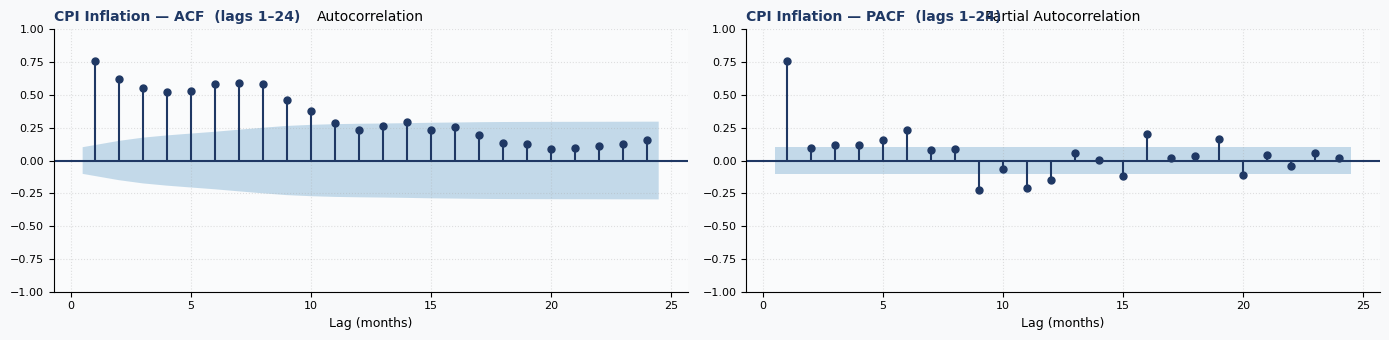

Saved → /content/drive/MyDrive/AGMR/outputs/figures/eda_09_acf_pacf_cpiinflationpct.png


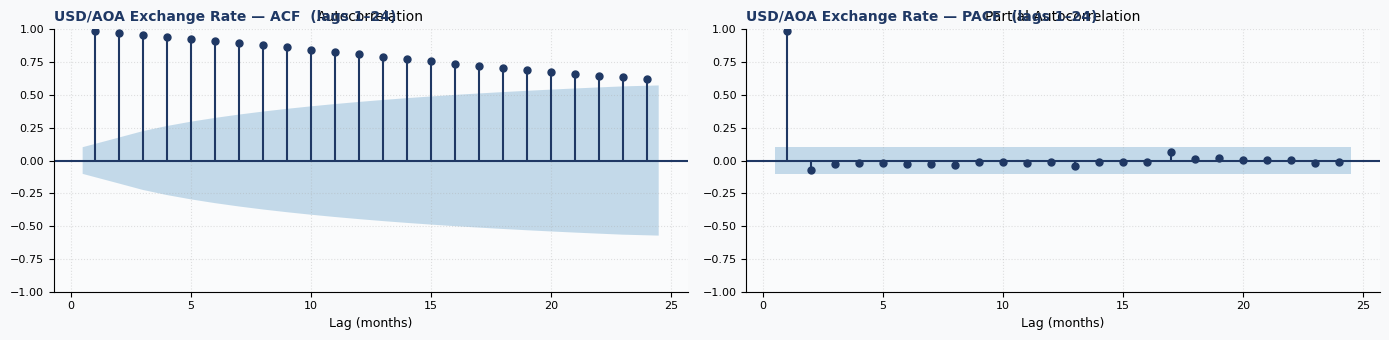

Saved → /content/drive/MyDrive/AGMR/outputs/figures/eda_09_acf_pacf_usdaoamonthly.png


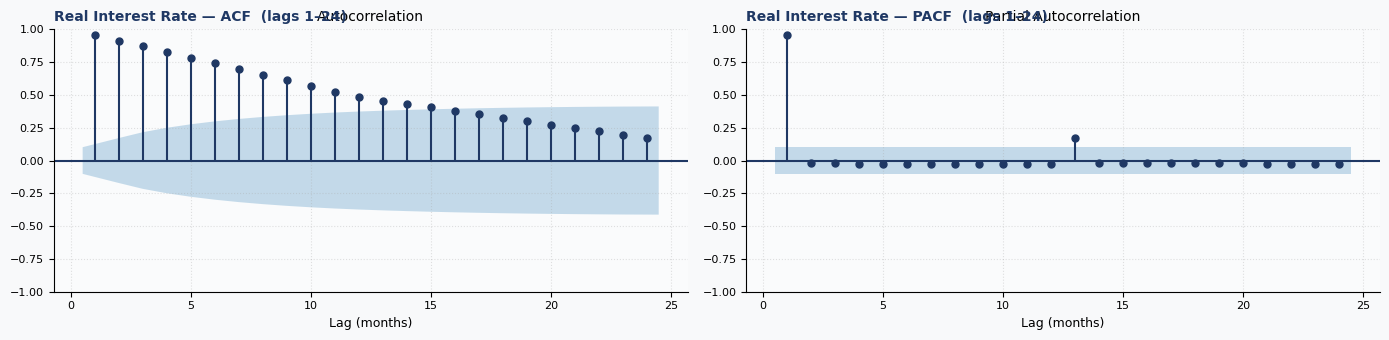

Saved → /content/drive/MyDrive/AGMR/outputs/figures/eda_09_acf_pacf_realinterestratemonthly.png


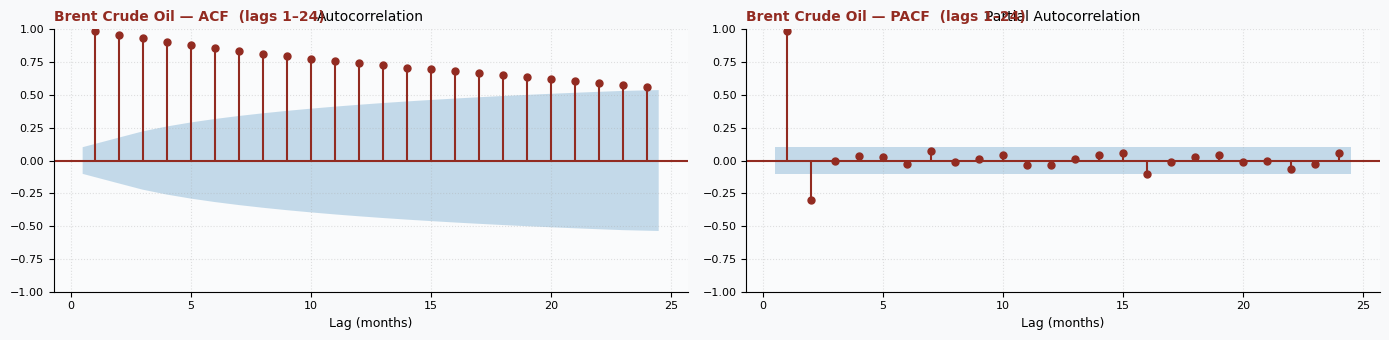

Saved → /content/drive/MyDrive/AGMR/outputs/figures/eda_09_acf_pacf_oilbrentusdbbl.png


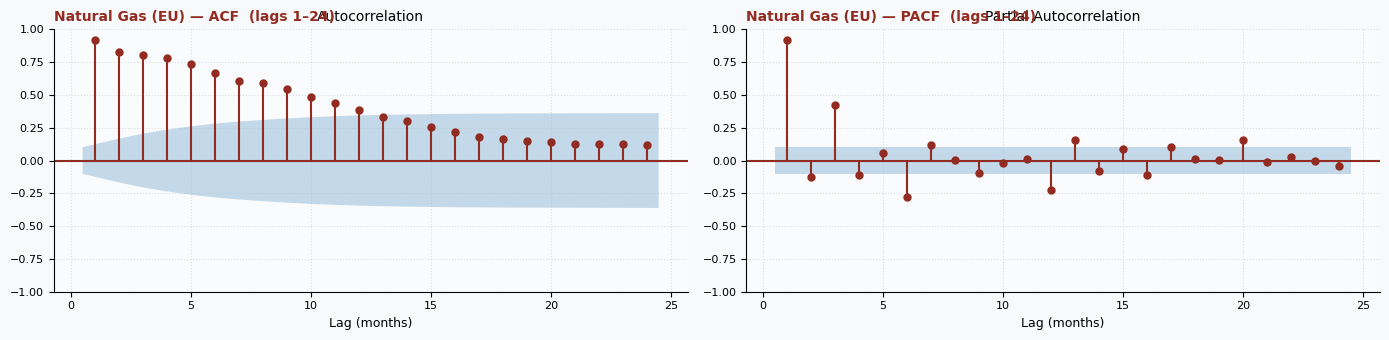

Saved → /content/drive/MyDrive/AGMR/outputs/figures/eda_09_acf_pacf_natgasusdmmbtu.png


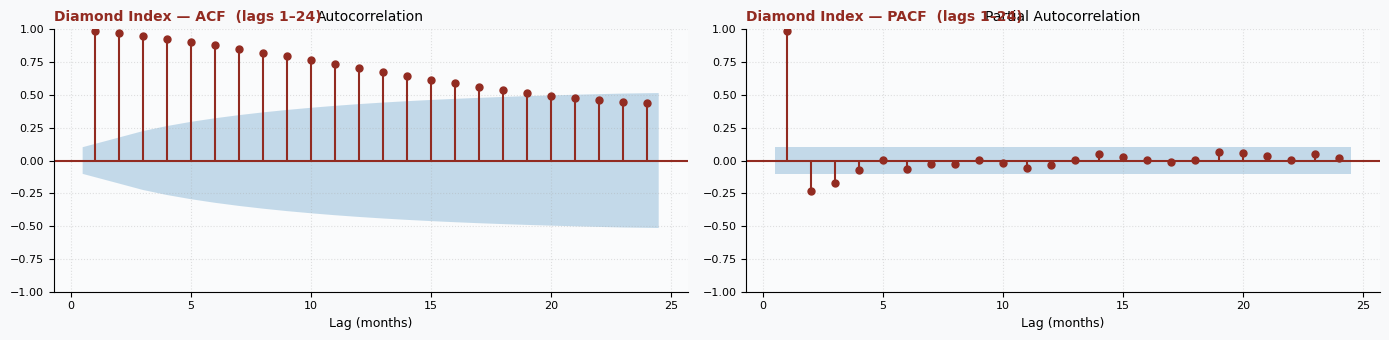

Saved → /content/drive/MyDrive/AGMR/outputs/figures/eda_09_acf_pacf_diamondusdcarat.png


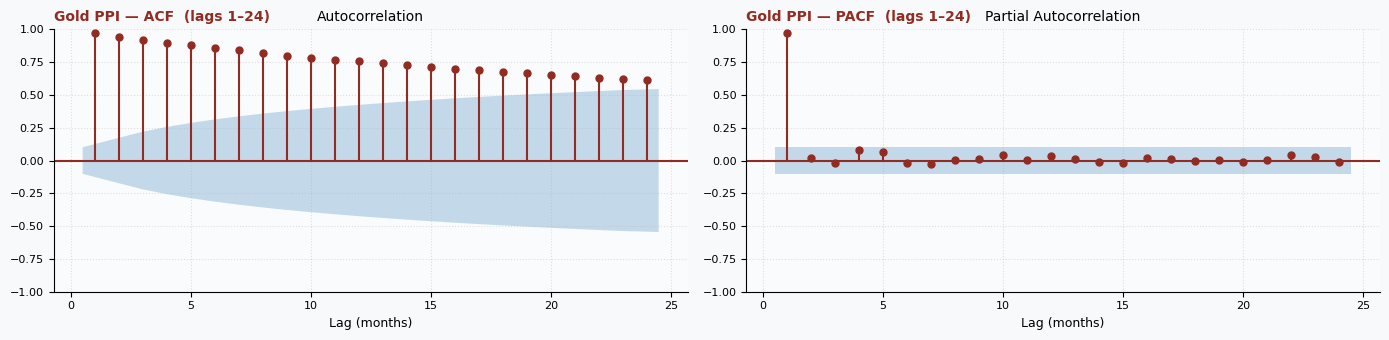

Saved → /content/drive/MyDrive/AGMR/outputs/figures/eda_09_acf_pacf_goldusd.png


In [116]:

# ACF and PACF


LAGS = 24

for col, label, unit, grp in SERIES:
    s = panel_subset[col].dropna()

    fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 3.5), facecolor='#F8F9FA')
    color = COLOR[col]

    plot_acf(s,  lags=LAGS, ax=ax1, color=color, vlines_kwargs={'colors': color},
             zero=False, alpha=0.05)
    plot_pacf(s, lags=LAGS, ax=ax2, color=color, vlines_kwargs={'colors': color},
              zero=False, alpha=0.05, method='ywm')

    ax1.set_title(f'{label} — ACF  (lags 1–{LAGS})',
                  fontsize=10, fontweight='bold', color=color, loc='left')
    ax2.set_title(f'{label} — PACF  (lags 1–{LAGS})',
                  fontsize=10, fontweight='bold', color=color, loc='left')
    ax1.set_xlabel('Lag (months)'); ax2.set_xlabel('Lag (months)')
    ax1.set_facecolor('#FAFBFC');   ax2.set_facecolor('#FAFBFC')

    plt.tight_layout()
    safe = col.replace('_', '')
    path = os.path.join(OUTPUT_DIR, f'eda_09_acf_pacf_{safe}.png')
    fig3.savefig(path, dpi=150, bbox_inches='tight', facecolor=fig3.get_facecolor())
    plt.show()
    print(f"Saved → {path}")


In [117]:

# Stationarity tests (ADF + KPSS)


def run_adf(series, maxlag=12):
    result = adfuller(series.dropna(), maxlag=maxlag, autolag='AIC')
    return {
        'ADF stat'   : round(result[0], 4),
        'p-value'    : round(result[1], 4),
        'Lags used'  : result[2],
        'n obs'      : result[3],
        'Crit 1%'    : round(result[4]['1%'],  4),
        'Crit 5%'    : round(result[4]['5%'],  4),
        'Crit 10%'   : round(result[4]['10%'], 4),
        'Reject H0'  : 'Yes — I(0)' if result[1] < 0.05 else 'No  — unit root'
    }

def run_kpss(series, regression='c'):
    result = kpss(series.dropna(), regression=regression, nlags='auto')
    return {
        'KPSS stat'  : round(result[0], 4),
        'p-value'    : round(result[1], 4),
        'Crit 1%'    : round(result[3]['1%'],  4),
        'Crit 5%'    : round(result[3]['5%'],  4),
        'Crit 10%'   : round(result[3]['10%'], 4),
        'Reject H0'  : 'Yes — non-stationary' if result[0] > result[3]['5%'] else 'No  — stationary'
    }

print("=" * 80)
print("STATIONARITY TESTS — panel_subset (LEVELS)")
print("H₀ ADF : series has a unit root (non-stationary)")
print("H₀ KPSS: series is stationary")
print("=" * 80)

adf_rows  = []
kpss_rows = []

for col, label, unit, grp in SERIES:
    s = panel_subset[col].dropna()

    adf_res  = run_adf(s)
    kpss_res = run_kpss(s)

    adf_rows.append({
        'Series'   : label,
        'N'        : adf_res['n obs'],
        'ADF stat' : adf_res['ADF stat'],
        'p-value'  : adf_res['p-value'],
        'Lags'     : adf_res['Lags used'],
        'Crit 5%'  : adf_res['Crit 5%'],
        'Decision' : adf_res['Reject H0']
    })
    kpss_rows.append({
        'Series'    : label,
        'KPSS stat' : kpss_res['KPSS stat'],
        'p-value'   : kpss_res['p-value'],
        'Crit 5%'   : kpss_res['Crit 5%'],
        'Decision'  : kpss_res['Reject H0']
    })

adf_df  = pd.DataFrame(adf_rows).set_index('Series')
kpss_df = pd.DataFrame(kpss_rows).set_index('Series')

print("\n── ADF Test (H₀: unit root) ──")
print(adf_df.to_string())

print("\n── KPSS Test (H₀: stationary) ──")
print(kpss_df.to_string())

# ── First differences stationarity check
print("\n" + "=" * 80)
print("STATIONARITY TESTS — FIRST DIFFERENCES")
print("=" * 80)

diff_rows = []
for col, label, unit, grp in SERIES:
    s    = panel_subset[col].dropna()
    diff = s.diff().dropna()

    adf_d  = run_adf(diff)
    kpss_d = run_kpss(diff)

    integ = 'I(0)' if adf_res['p-value'] < 0.05 else \
            'I(1)' if adf_d['p-value'] < 0.05  else 'I(2)'

    diff_rows.append({
        'Series'        : label,
        'ADF stat (Δ)'  : adf_d['ADF stat'],
        'p-value (Δ)'   : adf_d['p-value'],
        'KPSS stat (Δ)' : kpss_d['KPSS stat'],
        'p-value (Δ).1' : kpss_d['p-value'],
        'I(d)'          : integ
    })

diff_df = pd.DataFrame(diff_rows).set_index('Series')
print(diff_df.to_string())


STATIONARITY TESTS — panel_subset (LEVELS)
H₀ ADF : series has a unit root (non-stationary)
H₀ KPSS: series is stationary

── ADF Test (H₀: unit root) ──
                         N  ADF stat  p-value  Lags  Crit 5%         Decision
Series                                                                       
CPI Inflation          360   -8.2166   0.0000    11  -2.8696       Yes — I(0)
USD/AOA Exchange Rate  359   -0.0195   0.9569    12  -2.8696  No  — unit root
Real Interest Rate     359   -3.4395   0.0097    12  -2.8696       Yes — I(0)
Brent Crude Oil        370   -2.4876   0.1185     1  -2.8694  No  — unit root
Natural Gas (EU)       359   -3.3816   0.0116    12  -2.8696       Yes — I(0)
Diamond Index          369   -2.2119   0.2020     2  -2.8694  No  — unit root
Gold PPI               365    2.9625   1.0000     6  -2.8695  No  — unit root

── KPSS Test (H₀: stationary) ──
                       KPSS stat  p-value  Crit 5%              Decision
Series                               

/tmp/ipykernel_5342/2263994437.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression=regression, nlags='auto')
/tmp/ipykernel_5342/2263994437.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression=regression, nlags='auto')
/tmp/ipykernel_5342/2263994437.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series.dropna(), regression=regression, nlags='auto')
/tmp/ipykernel_5342/2263994437.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smalle

OUTLIER DETECTION — IQR method  (Q1 − 1.5×IQR  and  Q3 + 1.5×IQR)


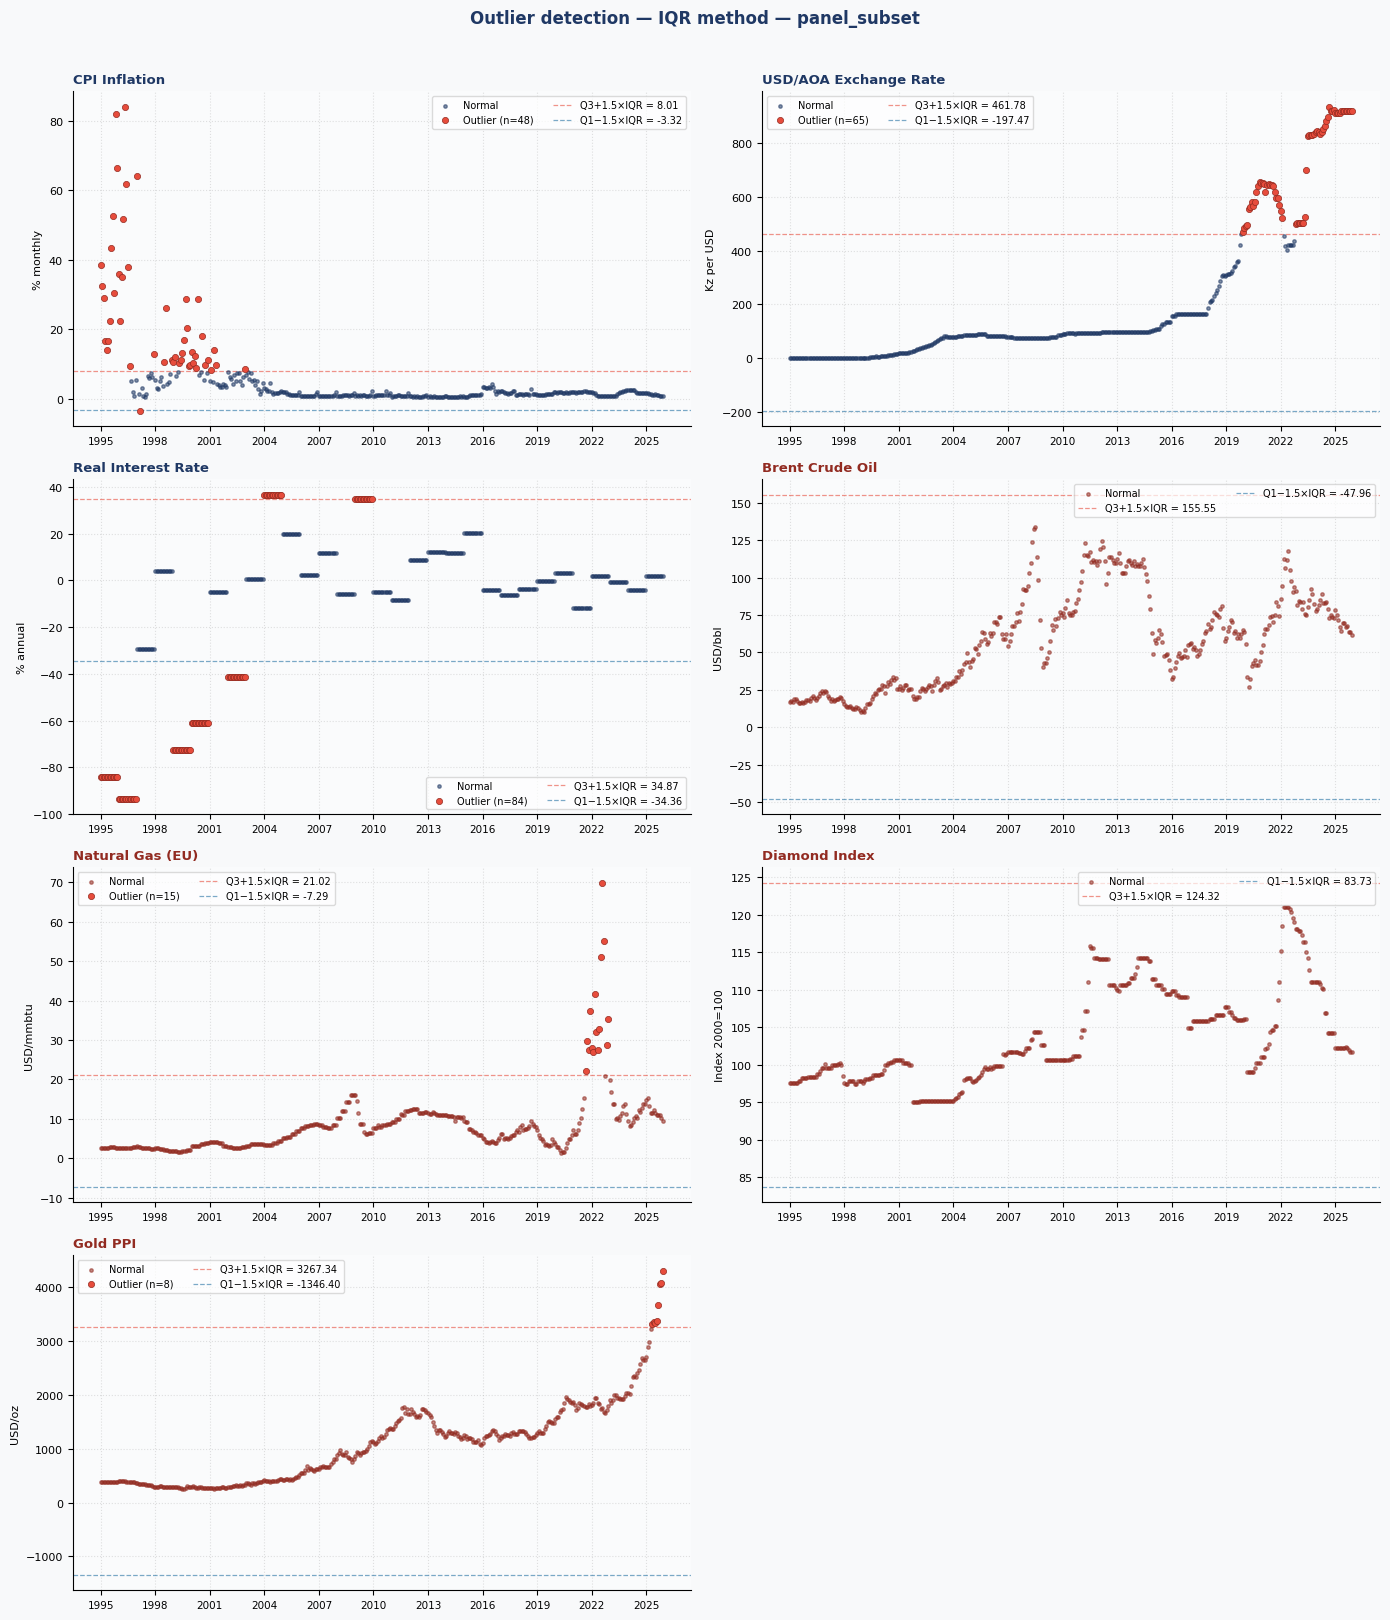

Saved → /content/drive/MyDrive/AGMR/outputs/figures/eda_10_outliers_iqr.png

Outlier summary:
                            Q1        Q3       IQR  Lower fence  Upper fence  N outliers                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       Outlier dates
Series                                                       

In [118]:

# Outlier detection (IQR)

print("=" * 80)
print("OUTLIER DETECTION — IQR method  (Q1 − 1.5×IQR  and  Q3 + 1.5×IQR)")
print("=" * 80)

outlier_summary = []

fig4, axes4 = plt.subplots(4, 2, figsize=(14, 16), facecolor='#F8F9FA')
axes4 = axes4.flatten()

for i, (col, label, unit, grp) in enumerate(SERIES):
    ax  = axes4[i]
    s   = panel_subset[col].dropna()
    sub = panel_subset[['date', col]].dropna()

    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr     = q3 - q1
    lo      = q1 - 1.5 * iqr
    hi      = q3 + 1.5 * iqr

    mask_out = (sub[col] < lo) | (sub[col] > hi)
    n_out    = mask_out.sum()
    color    = COLOR[col]

    # Plot normal values
    ax.scatter(sub.loc[~mask_out, 'date'], sub.loc[~mask_out, col],
               color=color, s=6, alpha=0.55, label='Normal', zorder=3)

    # Plot outliers
    if n_out > 0:
        ax.scatter(sub.loc[mask_out, 'date'], sub.loc[mask_out, col],
                   color='#E74C3C', s=20, zorder=4, label=f'Outlier (n={n_out})',
                   edgecolors='#922B21', linewidths=0.5)

    ax.axhline(hi, color='#E74C3C', linewidth=0.9, linestyle='--', alpha=0.6, label=f'Q3+1.5×IQR = {hi:.2f}')
    ax.axhline(lo, color='#2471A3', linewidth=0.9, linestyle='--', alpha=0.6, label=f'Q1−1.5×IQR = {lo:.2f}')

    ax.set_facecolor('#FAFBFC')
    ax.set_title(label, fontsize=9.5, fontweight='bold', color=color, loc='left')
    ax.set_ylabel(unit, fontsize=8)
    ax.legend(fontsize=7, framealpha=0.7, edgecolor='#CCCCCC', ncol=2)
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.get_xticklabels(), rotation=0, fontsize=7.5)

    # Print outlier details
    outlier_dates = sub.loc[mask_out, 'date'].dt.strftime('%Y-%m').tolist()
    outlier_vals  = sub.loc[mask_out, col].round(4).tolist()

    outlier_summary.append({
        'Series'       : label,
        'Q1'           : round(q1, 4),
        'Q3'           : round(q3, 4),
        'IQR'          : round(iqr, 4),
        'Lower fence'  : round(lo, 4),
        'Upper fence'  : round(hi, 4),
        'N outliers'   : n_out,
        'Outlier dates': ', '.join(outlier_dates) if outlier_dates else 'None'
    })

axes4[7].set_visible(False)
fig4.suptitle('Outlier detection — IQR method — panel_subset',
              fontsize=12, fontweight='bold', color='#1F3864', y=1.01)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'eda_10_outliers_iqr.png')
fig4.savefig(path, dpi=180, bbox_inches='tight', facecolor=fig4.get_facecolor())
plt.show()
print(f"Saved → {path}")

outlier_df = pd.DataFrame(outlier_summary).set_index('Series')
print("\nOutlier summary:")
print(outlier_df.to_string())

In [119]:
# EDA summary table

print("\n" + "=" * 80)
print("EDA SUMMARY TABLE — panel_subset")
print("=" * 80)

summary_rows = []
for j, (col, label, unit, grp) in enumerate(SERIES):
    s = panel_subset[col].dropna()

    # ADF decision from earlier
    adf_dec = adf_rows[j]['Decision']
    diff_dec = diff_rows[j]['I(d)']

    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    n_out = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()

    summary_rows.append({
        'Series'       : label,
        'Group'        : grp,
        'N'            : len(s),
        'NaN'          : panel_subset[col].isna().sum(),
        'Mean'         : round(s.mean(), 3),
        'Std'          : round(s.std(), 3),
        'Skew'         : round(s.skew(), 3),
        'IQR outliers' : n_out,
        'I(d)'         : diff_dec,
        'ADF decision' : 'I(0)' if 'I(0)' in adf_dec else 'I(1)',
    })

summary_df = pd.DataFrame(summary_rows).set_index('Series')
print(summary_df.to_string())

print(f"\n\nAll EDA figures saved to: {OUTPUT_DIR}")
print("Files generated:")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    if fname.startswith('eda_'):
        print(f"  {fname}")


EDA SUMMARY TABLE — panel_subset
                               Group    N  NaN      Mean      Std    Skew  IQR outliers  I(d) ADF decision
Series                                                                                                    
CPI Inflation          Macroeconomic  372    0    4.9780  10.6940  4.5960            48  I(1)         I(0)
USD/AOA Exchange Rate  Macroeconomic  372    0  203.3440 261.8630  1.6210            65  I(1)         I(1)
Real Interest Rate     Macroeconomic  372    0   -8.6140  30.8190 -1.3620            84  I(1)         I(0)
Brent Crude Oil            Commodity  372    0   59.0410  31.4560  0.2760             0  I(1)         I(1)
Natural Gas (EU)           Commodity  372    0    8.0060   7.4180  3.8580            15  I(1)         I(0)
Diamond Index              Commodity  372    0  103.8320   6.3700  0.7300             0  I(1)         I(1)
Gold PPI                   Commodity  372    0 1080.9970 749.3990  1.1410             8  I(2)         I(1)


A

Príncipe Zanguilo